In [75]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

## Note!
<span style="color:#000066">
Sections of writing that have not changed are rendered in this blue colour. 
</span>

# Section the First: The death, child marriage, and slavery of kids books. 


<span style="color:#000066">
The Dear Canada books are an anthology of childrens books. I love them! Each is from the perspective of a young girl (10-14) living through a moment of Canadian history (wars, natural disasters, political developments, oppression experiences, etc). They can be a signifigant force to shape readers perception of national identity (especially when it is your only ressource for national history, because your province is separatist and only teaches provincial history). 
Many document immigrant experiences. How those experiences might be the most contemporaniously relevant depications for such a high immigration country with tubulent attitudes towards it. So how is it experienced in these books?
This report uses ensemble model sentiment analysis on the foundation of four books from the anthology:

* A Sea of Sorrows: The Typhus Epidemic Diary of Johanna Leary
    * Set in 1847, it follows a young girl immigrating to Canada with her family in response to the potato famine and colonial neglegence affecting Ireland. Both her parents and her baby sibling die before arrival, then her brother is told she is dead and leaves her. She lives for a while in a convent, then works for a disciminatory family, then works for a kind family who essencially absorb her into the family. When things are finally going well, the father is brutally injured while working in the logging industry and that family decides to return to England (it is truly sorrowful), however, they invite her to return with them and she decides to go. At the last minute, her brother finds her and they join their uncle at his farm. 

* With Nothing but Our Courage: The Loyalist Diary of Mary MacDonald
    * Set in 1783, their family are loyal to the Birtish during the American Revolution and are driven from their home. They make the journey to Quebec where the King provides them land and some supplies, but they must restart, are undersupplied and face a harsh winter. They eventually settle in nicely with a community of loyalists. Only one of her family members die, her baby sister. 

* Alone in an Untamed Land: The Filles Du Roi Diary of Helene St. Onge
    * Set in 1666, Helene and her sister are recently orphaned. Helene tags along with her sister, who is a fille du roi (a young woman set to marry and poplutate the colony), and they sail to New France. The odler sister dies, and eventually Helene takes her place as a fille du roi. Life in New France is harsh, with hard winters and threats of Iroquis attack. Eventually, she marries into the Metis community and becomes the step mother to her best-friend. She is 13 at the start of the book and 14 when she marries. 

* A Desperate Road to Freedom: The Underground Railroad Diary of Julia May Jackson
    * Set in 1863, Julias family escapes their forced labour on a Virginia tobacco plantation in response to the emancipation proclaimation. They are desperate to keep their family together, after three of their children have already been sold and lost. They follow the Underground Railroad to Canada, eventually settling in southern Ontario. They build a life there learning new skills to survive in Canada. 

* A Prairie as Wide as the Sea: The Immigrant Diary of Ivy Weatherall
    * Set in 1926, Ivy Weatherall and her family leave a comfortable life in London for the promised riches of Canada's expanding West. They expect to join a well settled family member and to be able to buy their own land, but find themselves living in a sod hut on a rented farm. Ivy recounts learning the new skills expected of a young farm girl. No one dies! 

* Footsteps in the Snow: The Red River Diary of Isobel Scott
    * Set in 1815, the book begins with "Mother is dead." Isobel travels with her two brothers and father amoung the Selkirk Settlers who seek their own land and fortune in Ruperts land (Manitoba). They find themselves caught in the fur-trading rivalry between the Hudson's Bay Company and the North West Company, and struggle seriously with the harsh winters. Their father eventually remarries a Cree woman, and eventually they able to put down roots. 

I manually tagged hundreds of sentences from each book, excluding front and back matter (eg epilogue, historical note, etc). Each sentence could be any subset of neutral, positive and negative, with respect to their sentiment towards the immigration experience. A sentence like: "Mr. Tattersall has died." would be tagged as neutral, because it does not comment on migration. Whereas "He said it would have been better if Thomas had died at home where he could be buried in the ground with a priest to say words over him, instead of being tossed into the ocean like so much refuse." would be tagged as negative, because, gosh, thats depressing and definitely about the journey. The commentary should be internal to the sentence, so I did my best to understand each phrase outside of my knowlege of the book. This was frequently ambigious and my work is almost certainly dubious. I originally assigned only one tag per sentence, then retagged with any number of tags. This revealed to me how inconsistent I am.

Neutral sentences are signifigantly overrepresented. Naturally, there are more basic sentences then emotionally charged ones, but I suspect because the writing is tailored to kids each individual sentence might, on average, contain less complexity or profound emotional reflection which might worsen the bias. 
</span>


The process of gathering the sentences from the books has not changed meaningfully since the first assignment, therefore I have relegated it to the Appendix. However, I did actually revise that section, to make it cleaner and a smoother process.

Since the last assignment, I have begun a process of changing the labeling scheme to have four binary classifications: positive, neutral, negative, and immigration. In this scheme, any sentence that shows one of the sentiments will be labeled as such, and the immigration variable describes it's relevance to that topic. This will make the data cleaner and more adaptable for future projects that extend to the whole series. However, it will take a good deal of time to adjust the data labeling, and in the meantime the models need all the data they can get. Therefore, for now, this assignment still uses the old scheme, but appropriately filtering for combinations of the 4 variables to resemble the previous 3 variables. 

When adding data to the database this time, I used the logistic model from the previous assignment to assignment sentiment scores by sentence and then sorted the spreadsheet such that I could label the most positive and most negative examples. This new data showed mostly minority class examples, which has helped to improve the imbalance. It also helps to identify interesting sentences that may have decieved the previous model, creating examples of rich neutral sentences or minority cases which are the inverse of the expected. 

<span style="color:#000066">
All data by book:


* A Sea of Sorrows: 
    * https://docs.google.com/spreadsheets/d/1wD1FXjlnSc4dNbAMG-ao3kaJ703kUrh9fN_qmiUsESQ/edit?usp=sharing

* With Nothing but Our Courage:
    * https://docs.google.com/spreadsheets/d/1mNxHFrLdaTxogkuXRKXPAowVM5RVcLqj4_0_fg9J7JY/edit?usp=sharing

* Alone in an Untamed Land: 
    * https://docs.google.com/spreadsheets/d/11Oo0RVQLp67KDq-6aKBtkG4sJUH1M-a48dOulzs0nRw/edit?usp=sharing 

* A Desperate Road to Freedom: 
    * https://docs.google.com/spreadsheets/d/1kUvav-Nw_3gy3ovdhktnaEf96SWWYTk-TzwVFTJ07IY/edit?usp=sharing

* Footsteps in the Snow
    * https://docs.google.com/spreadsheets/d/1lgwuJVaU-7Kv44IyCcicrF-7f_u8I6FdE7L4DFfPrq4/edit?usp=sharing

* A Prarie as Wide as the Sea
    * https://docs.google.com/spreadsheets/d/1fY5A0q57KMEGZ7heqP8C_8vT5zov41t6owsUj_uwfKg/edit?usp=sharing 
</span>

# Section the Second: Gathering Labeled Data


The raw data for this project exists across three separate file structures, reflecting an ongoing transition between labeling schemes. Consolidating these into a single analysis-ready dataframe requires source-specific filtering before concatenation.

The first source consists of the original tagged sentence files, one per book, stored under t_sentences_unordered_dfs/. These files use an early three-label scheme in which each sentence was assigned any combination of positive, negative, and neutral flags. Because this project focuses specifically on sentiment about the immigration experience, only sentences tagged neutral == 1 are retained from these files. In this scheme, "neutral" was used to indicate relevance to the immigration topic and/or emotional neutral, a flawed and confused variable which motivationed the new scheme. A book_name column is derived from the filename at this stage, since the old files do not include it.

The second source consists of augmented sentence files stored under t_augmented/, which follow a revised four-label scheme adding an explicit immigration binary flag. From these files, only rows where immigration == 1 are retained, filtering to sentences that are directly relevant to the migration experience regardless of their sentiment. These files already include a book_name field and a version column distinguishing original sentences from their augmented variants.

A third source, stored under t_extreme_sentences/, contains labeled sentences that were chosen as the most positive and/or negative diary entries by the logistic model developed in the previous assignment. By using that model to identify emotional sentences, I was able to find more minor class sentences and label more efficiently. There are not augmentation sentences made from their inspiration. 

After source-specific filtering, the three training sources are concatenated into a single dataframe. Because the version column only exists in the new-scheme files, NaN values introduced by the concatenation are filled with "original".

In [109]:
import pandas as pd
import glob
import os

dfs = []

# 1) Old dataset of sentences, filtered to only include neutral examples
old_path = "dataframes/tagged/t_sentences_unordered_dfs/*.csv"
old_files = glob.glob(old_path)

for file in old_files:
    df_old = pd.read_csv(file)
    book_name = os.path.splitext(os.path.basename(file))[0]
    before = len(df_old)
    df_old = df_old[df_old["neutral"] == 1].copy()
    after = len(df_old)
    df_old["book_name"] = book_name
    dfs.append(df_old)

# 2) Labeled minority examples mixed with their augmentation examples
aug_path = "dataframes/tagged/scheme_two/t_augmented/*.csv"
aug_files = glob.glob(aug_path)

for file in aug_files:
    df_new = pd.read_csv(file)
    before = len(df_new)
    df_new = df_new[df_new["immigration"] == 1].copy()
    after = len(df_new)
    dfs.append(df_new)

# 3) Unaugmented examples, with higher minority frequency found via sorting on logistic regression model
extreme_path = "dataframes/tagged/scheme_two/t_extreme_sentences/*.csv"
extreme_files = glob.glob(extreme_path)

for file in extreme_files:
    df_e = pd.read_csv(file)
    before = len(df_e)
    df_e = df_e[df_e["immigration"] == 1].copy()
    after = len(df_e)
    dfs.append(df_e)

# 4) Concatenation and clean
df = pd.concat(dfs, ignore_index=True)
df = df.dropna(subset=["sentence"])
df["version"] = df["version"].fillna("original")
df.drop(columns=["Positive_score", "Positive_pred", "Negative_score", "Negative_pred", "Neutral_score", "Neutral_pred"], inplace=True) # dropping artifact of extreme sentence selection process

print("\nNumber of training+val sentences:", len(df))
df.head()


Number of training+val sentences: 3018


,chapter_id,date,sentence,neutral,positive,negative,book_name,version,immigration,entry_id
0,ch8,Decembre 1666,"“Well, well.",1.0,0.0,0.0,AinUTL,original,NaN,NaN
1,ch9,Janvier 1667,Strands of his hair were stuck to his cheek.,1.0,0.0,0.0,AinUTL,original,NaN,NaN
2,ch5,Septembre 1666,"I would wait as well, I answered, and I turned...",1.0,0.0,0.0,AinUTL,original,NaN,NaN
3,ch6,Octobre 1666,My income from my business as a merchant is mo...,1.0,0.0,0.0,AinUTL,original,NaN,NaN
4,ch5,Septembre 1666,I excused myself and went down to my cabin to ...,1.0,0.0,0.0,AinUTL,original,NaN,NaN


# Section the Third: Pre-processing & Feature Engineering 

## Data Augmentation

The original labeled dataset suffered from severe class imbalance. Neutral sentences — those relevant to immigration but carrying no strong sentiment — constituted approximately 90% of the corpus, leaving only 150 positive and 155 negative examples. A classifier trained on this distribution has little incentive to learn the minority classes: it can achieve ~90% accuracy by predicting neutral for everything, which is the exact failure mode observed in earlier iterations of this project.

To address this, all positive and negative sentences were augmented to produce two additional variants each. Augmentation was performed using Claude LLM, prompted to apply surface-level transformations that preserve semantic content: reordering sentence elements, substituting synonyms, and adding or removing words that do not alter meaning. For example:

* Original: "He was sorry he ever left Ireland."
* Variant 1: "He regretted having left Ireland."
* Variant 2: "Sorry he had ever left Ireland, he said."

Crucially, these transformations are designed to vary the form of a sentence without changing its label. The augmented variants inherit the exact same positive, negative, and neutral flags as their original. This is the justification for treating augmentation as a legitimate data expansion technique rather than fabrication: the label is preserved by construction.

The result was a significant improvement in balance, raising the positive and negative shares from ~7.5% each to roughly 22% each, and increasing the total corpus from 1,996 to 2,705 sentences. The figure below shows the distribution by book before and after augmentation, with augmented data shown in grey above the colored original-data segments.

One important methodological constraint follows from this augmentation strategy: because augmented sentences are near-paraphrases of their originals, the two must never appear on opposite sides of a train/test split. If an original sentence lands in training and its clone lands in validation, the model is partially evaluated on data it has effectively seen, inflating performance estimates. This is addressed in the splitting strategy described in Section Four.

In [110]:
import matplotlib.pyplot as plt
import pandas as pd

label_cols = ["positive", "negative", "neutral"]

# -- Summary, with augmentation examples included --
total_counts = df[label_cols].sum()

summary_table = pd.DataFrame({
    "Count": total_counts,
    "Proportion": total_counts / total_counts.sum()
})

print("\n===== Data Summary =====")
print("\nTotal Sentences:", len(df))
display(summary_table)


# -- Summary, without augmentation  --
df["_is_aug"] = df["version"].fillna("original") != "original"

original_only_counts = df.loc[~df["_is_aug"], label_cols].sum()
original_only_dist = original_only_counts / original_only_counts.sum()

original_summary_table = pd.DataFrame({
    "Count": original_only_counts,
    "Proportion": original_only_dist
})

print("\n===== Data Summary (Excluding Augmentation) =====")
print("\nTotal Sentences:", len(df.loc[~df["_is_aug"]]))
display(original_summary_table)





===== Data Summary =====

Total Sentences: 3018


,Count,Proportion
positive,727.0,0.204731
negative,766.0,0.215714
neutral,2058.0,0.579555



===== Data Summary (Excluding Augmentation) =====

Total Sentences: 2404


,Count,Proportion
positive,345.0,0.130533
negative,370.0,0.139992
neutral,1928.0,0.729474


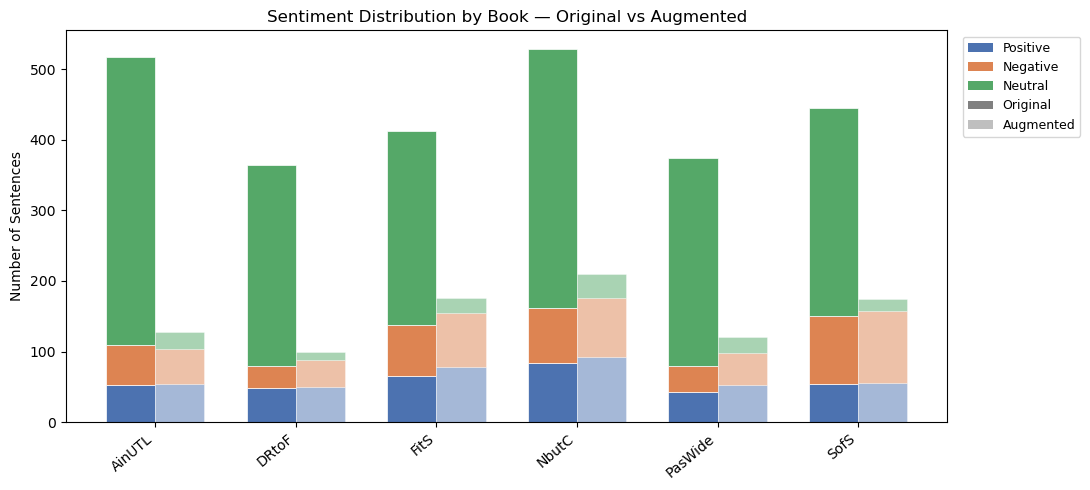

In [111]:

# -----------------------------------------
# Build counts split by original / augmented
# -----------------------------------------
orig_counts = df[~df["_is_aug"]].groupby("book_name")[label_cols].sum()
aug_counts  = df[df["_is_aug"]].groupby("book_name")[label_cols].sum().reindex(orig_counts.index, fill_value=0)

df.drop(columns=["_is_aug"], inplace=True)

# -----------------------------------------
# Plot: paired bars, original vs augmented
# each stacked by sentiment
# -----------------------------------------
books    = orig_counts.index.tolist()
n_books  = len(books)
n_labels = len(label_cols)
colors   = ["#4C72B0", "#DD8452", "#55A868"]

bar_width = 0.35
x = range(n_books)

fig, ax = plt.subplots(figsize=(11, 5))

for i, (counts, label_suffix, offset) in enumerate([
    (orig_counts, " (original)",  -bar_width / 2),
    (aug_counts,  " (augmented)",  bar_width / 2),
]):
    bottoms = [0] * n_books
    for j, col in enumerate(label_cols):
        vals = counts[col].tolist()
        bars = ax.bar(
            [xi + offset for xi in x],
            vals,
            bar_width,
            bottom=bottoms,
            color=colors[j],
            label=col.capitalize() + label_suffix if i == 0 else f"__{col}{i}",
            alpha=1.0 if i == 0 else 0.5,
            edgecolor="white",
            linewidth=0.5
        )
        bottoms = [b + v for b, v in zip(bottoms, vals)]

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[j], label=label_cols[j].capitalize()) for j in range(n_labels)
] + [
    Patch(facecolor="grey", alpha=1.0, label="Original"),
    Patch(facecolor="grey", alpha=0.5, label="Augmented"),
]

ax.set_xticks(list(x))
ax.set_xticklabels(books, rotation=40, ha="right")
ax.set_ylabel("Number of Sentences")
ax.set_title("Sentiment Distribution by Book — Original vs Augmented")
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

Recall, in the previous, unaugmented and randomly labeled data pool, representation for negative and positive sentences was very poor. 

===== Original Overall Label Counts =====

positive     150

negative     155

neutral     1789


Total Sentences: 1996


===== Original Overall Label Distibution =====

positive     0.075150

negative     0.07765

neutral     0.89629



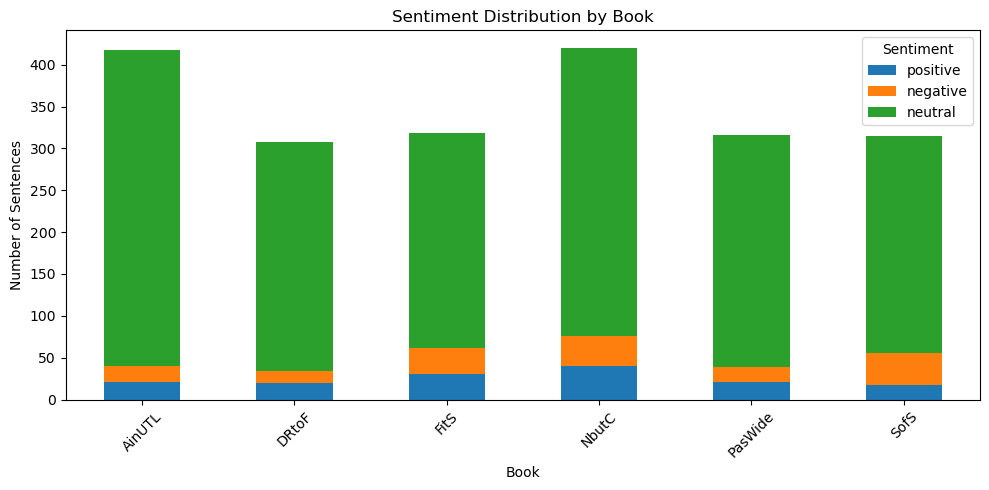

Even before augmentation, the more recent round of labeling (dispite only tagging ~400 more sentences) improved each minority share by almost double (from ~7% to ~13%). Augmenting imrpoved that even more, raising the minority shares to about 20% each. Overall, the amount of total data has grown by 150%. Unfortunately, there should still be more data, but this is a big improvement. 

## DistilBERT Embeddings

To translate natural language into a form suitable for neural network classifiers, this project uses DistilBERT as a frozen feature extractor. DistilBERT is a compressed version of the BERT transformer, trained via knowledge distillation: a smaller "student" model is trained to reproduce the behaviour of the full "teacher" BERT model, achieving approximately 97% of its performance at 40% fewer parameters. It was pretrained on a concatenation of English Wikipedia and the Toronto Books Corpus, optimising three objectives simultaneously: masked language modelling loss (predicting randomly masked tokens), distillation loss (matching the teacher's output distribution), and cosine embedding loss (aligning the student's hidden representations geometrically with the teacher's).

The key property that makes DistilBERT useful here is that its representations are *contextualised*: the embedding of a word is not fixed but depends on the words around it. A simple bag-of-words or TF-IDF model would represent "not bad" as two independent tokens, missing that the negation fundamentally changes the sentiment. DistilBERT encodes the whole sentence simultaneously and produces token representations that already reflect this context.

In the previous assignment, which used logistic and linear SVM classifiers, the full sentence was collapsed into a single 768-dimensional vector before classification. Those models require a fixed-size input — a single "point in space". The models in this assignment (MLP, CNN, and LSTM) are capable of operating on sequences of vectors, and in some cases explicitly designed to learn from their order. It would be wasteful to discard that structure before classification. Therefore, rather than extracting the sentence-level embedding, the full token-level output of DistilBERT is retained.

Concretely, the tokenisation pipeline works as follows:

**Tokenisation**: Each sentence is split into subword tokens and two special markers are added (`[CLS]` at the start (a summary token) and `[SEP]` at the end).

* e.g. `"I love Canada."` → `['[CLS]', 'i', 'love', 'canada', '.', '[SEP]']`


**Vocabulary encoding**: Tokens are mapped to integer IDs from DistilBERT's fixed vocabulary.

* e.g. `[101, 1045, 2293, 2710, 1012, 102]`

**Padding and masking**: All sentences are padded to the same length (128 tokens) so they can be batched into a matrix. An attention mask records which positions are real tokens (1) versus padding (0), so the model ignores the padding during processing.

* e.g. padded tokens `[101, 1045, 2293, 2710, 1012, 102, 0, 0, 0, 0, 0, 0]` and the complementary attention mask `[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]`


**Embedding extraction**: Token IDs are passed through the frozen DistilBERT model. The output is the `last_hidden_state`: a matrix of shape `(seq_len, 768)` for each sentence, where each row is a 768-dimensional contextualised embedding for one token.

After processing all sentences, the full embedding array has shape `(n_sentences, 128, 768)`. This is the input to all three classifiers. DistilBERT's parameters are frozen throughout — it is used strictly as a feature extractor, not fine-tuned. The concern is that the labeled corpus (~2,700 sentences) is too small to meaningfully update a model with 66 million parameters without catastrophic forgetting or overfitting.

<span style="color:#000066">

### Knowledge Distillation
</span>


<span style="color:#000066">

#### Distilation Loss
In distilation loss, we incorperate a pretrained model into the training process of the smaller model, as shown bellow.

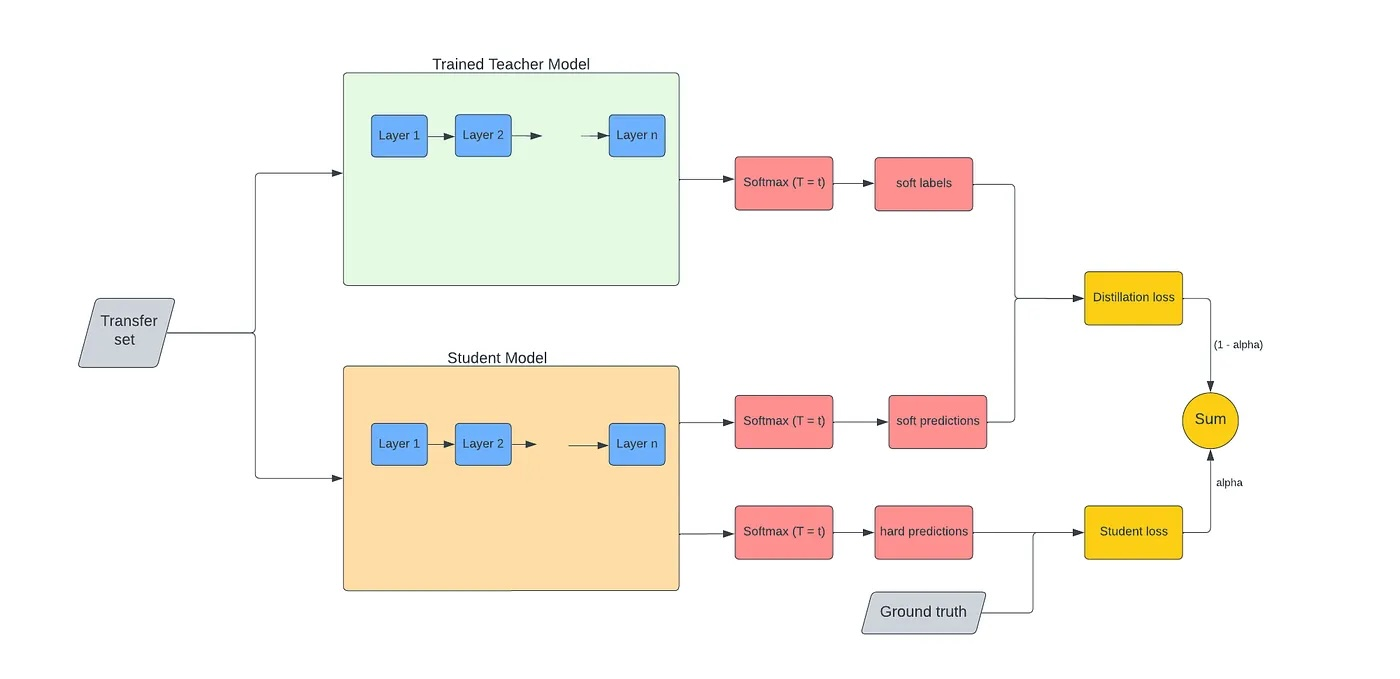

In the case of DistilBert, both the teacher and student models were trained on the same corpus, a concatenation of English Wikipedia and Toronto Book Corpus. A share of this input is reserve from other opperations to act as the transfer set, which is used for the distilation learning. Rather than just DistilBert just observing and responding to it's own predictions for success and failure, it also checks if it agreed with it's teacher model. 

We pass forward through both models, but only back propagate through the student model. 

We predict with the Softmax function:

$$\sigma(z_i) = \frac{e^{\frac{z_{j}}{t}}}{\sum_{j=1}^K e^{\frac{z_{j}}{t}}} \ \ \ for\ i=1,2,\dots,K$$
<br>

The distilation loss is a combination of the teacher and student Softmax, according to KL-divergence loss:

$$D_{KL}(P||Q) = \sum_{i} P(i) \log \frac{P(i)}{Q(i)}$$
<br>

Here, we set the tempurature variable of the Softmax, t, to t > 1, to soften the confidence of the teacher (smoothing the probability distribution) to give the student more informative gradients (in contrast, we have t = 1 to calculate student loss). 

The total loss sum (for distilation) is calculated as:

$$sum = (alpha * Student model loss) + ((1 — alpha)* distillation loss)$$
<br>
<br>

#### Cosine embedding loss
Simultaniously, cosine embedding loss is calculated. Cosine loss compares the hidden layer vectors in the teacher and student models to encourage the student’s hidden representations to occupy a similar geometric space as the teacher’s. It is calculated as:
$$cosdist = 1 - \frac{x \cdot y}{|x||y|}$$
<br>
<br>

#### Masked language modelling loss
Finally, DistilBert is trained by masking a random subset of words within the training corpus and asking the model to predict those words. Over different epochs different subsets of words are masked. This is independent of the teacher. The teacher model is also trained with masked language modelling loss. 

<br>
<br>

These three forms are taken together in a linear combination to train the student. We could fine tune this model to make predictions for the sentiment class of our text, however, the concern is that there isn't enough data to influence the model appropriately. So instead, we use the sophistication of the DistilBert to generate embeddings that are sensitive to more subtle and complex emotion representation, and use those embeddings to train our own models. 
</span>

In [79]:
# Load DistilBERT model and tokenizer
from transformers import DistilBertModel, DistilBertTokenizer
import torch.nn as nn
import torch
import numpy as np

# Load pre-trained DistilBERT
distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Freeze DistilBERT parameters
for param in distilbert.parameters():
    param.requires_grad = False

# Tokenize and encode input text
sentences = df["sentence"].tolist()
inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt", max_length=128)
input_ids = inputs['input_ids']
attention_masks = inputs['attention_mask']

# Extract token embeddings (full sequence)
with torch.no_grad():
    token_embeddings = distilbert(input_ids, attention_mask=attention_masks).last_hidden_state

# Convert token embeddings to numpy for compatibility
X_embeddings = token_embeddings.numpy()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The tokenizer is converting each word into a reference to the reference dictionary. Because all sentences must have the same length, the attention mask is the element that marks what amount of that fixed length is actually occupied with the sentence and is worth paying attention to. 

In [80]:
print("--Token IDs and Attention Masks for the first sentence--")
print(input_ids[0])  # Example token IDs for the first sentence
print(attention_masks[0])  # Example attention mask for the first sentence  
print(token_embeddings[0])  # Token embeddings for the first sentence (shape: [max_len, hidden_dim])

--Token IDs and Attention Masks for the first sentence--
tensor([ 101, 1523, 2092, 1010, 2092, 1012,  102,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0])
tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([[ 0.0617,  0.1328,  0.1379,  ...,  0.1530,  0.2001,  0.1276],
        [ 0.0679,  0.3250, 

In [81]:
y = np.stack([
    df["positive"].values,
    df["negative"].values,
    df["neutral"].values
], axis=1)

# Sanity checks
print("Labels shape (number of samples, labeling catagories):", y.shape)
print("Number of sentences labeled...")
print(" positive:", np.sum(y[:, 0]))
print(" negative:", np.sum(y[:, 1]))
print(" neutral:", np.sum(y[:, 2]))
print("Sample labels (first 5):\n", y[:5])

Labels shape (number of samples, labeling catagories): (3018, 3)
Number of sentences labeled...
 positive: 727.0
 negative: 766.0
 neutral: 2058.0
Sample labels (first 5):
 [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


# Section the Fourth: Data Splitting and Analysis Design

## Task Framing

This project is a **multi-label binary classification** task. Each sentence must be assigned a subset of three sentiment labels where any combination is valid. This is categorically different from multi-class classification, where exactly one label is assigned per sample. In multi-class classification, the labels are mutually exclusive and the model is asked to choose one; here, a sentence expressing relief at having survived a dangerous crossing might simultaneously be positive (survival) and negative (the danger), and the model must be able to predict both.

This distinction has architectural consequences throughout the pipeline. A softmax output layer, which forces all class probabilities to sum to 1, is inappropriate: it is designed for mutually exclusive classes. Instead, each label is treated as an independent binary prediction, and a sigmoid activation is applied separately to each output. The loss function is binary cross-entropy computed independently per label, rather than categorical cross-entropy. These choices are discussed further in Sections Five and Six.

## Splitting Strategy

Constructing valid train, validation, and test splits requires care because of the augmentation described in Section Three. Many of the original sentence has two augmented siblings that are near-paraphrases of it. A naive random shuffle across all rows risks placing an original sentence in the training set and one of its clones in validation, and the model would be partially evaluated on data it has, in effect, already seen. This inflates performance estimates and makes validation a less honest signal.

The solution is to split on *groups* rather than individual rows, where a group is defined as one original sentence and all its augmented variants. `GroupShuffleSplit` from scikit-learn enforces this: it guarantees that all members of a group land in the same partition, so no group is ever split across train and validation. Groups are identified by the combination of `book_name`, `chapter_id`, and `date`. This combination may group together sentences that are simply from the same diary entry occationally, but there are not too many sentences from the same entries, so that shouldn't be a significant effect. A sanity check after splitting confirms that no group ID appears in more than one partition.

In [104]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np


# Build a group ID per original + its clones
# Every row gets the index of its original sentence

df["version"] = df["version"].fillna("original")

# Create group key from the identifying columns
group_cols = ["book_name", "chapter_id", "date"]
df["_group"] = df[group_cols].apply(tuple, axis=1)

# Map each group key to an integer group ID
group_keys = df["_group"].unique()
group_to_id = {g: i for i, g in enumerate(group_keys)}
groups = df["_group"].map(group_to_id).to_numpy()

idx = np.arange(len(df))


# -------- First split: carve out test (15%) --------
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss_test.split(idx, groups=groups))


# -------- Second split: carve val from train pool (20% of trainval) --------
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss_val.split(
    trainval_idx, groups=groups[trainval_idx]
))
train_idx = trainval_idx[train_idx]
val_idx   = trainval_idx[val_idx]


# Build arrays
X_tr   = X_embeddings[train_idx]
X_val  = X_embeddings[val_idx]
X_test = X_embeddings[test_idx]

y_tr   = y[train_idx]
y_val  = y[val_idx]
y_test = y[test_idx]

# Cleanup
df.drop(columns=["_group"], inplace=True)

# -----------------------------------------
# Split summary table
# -----------------------------------------
split_summary = pd.DataFrame({
    "Total Rows": [
        len(X_tr),
        len(X_val),
        len(X_test)
    ],
    "Positive": [
        y_tr[:, 0].sum(),
        y_val[:, 0].sum(),
        y_test[:, 0].sum()
    ],
    "Negative": [
        y_tr[:, 1].sum(),
        y_val[:, 1].sum(),
        y_test[:, 1].sum()
    ],
    "Neutral": [
        y_tr[:, 2].sum(),
        y_val[:, 2].sum(),
        y_test[:, 2].sum()
    ]
}, index=["Train", "Validation", "Test"])

print("===== Dataset Split Summary =====")
display(split_summary)

# Sanity check — no group should appear in more than one split
train_groups = set(groups[train_idx])
val_groups   = set(groups[val_idx])
test_groups  = set(groups[test_idx])
assert train_groups.isdisjoint(val_groups),  "Leakage: train/val share a group!"
assert train_groups.isdisjoint(test_groups), "Leakage: train/test share a group!"
assert val_groups.isdisjoint(test_groups),   "Leakage: val/test share a group!"
print("Sanity check passed — no group leakage.")

===== Dataset Split Summary =====


,Total Rows,Positive,Negative,Neutral
Train,2070,444.0,497.0,1449.0
Validation,388,111.0,126.0,247.0
Test,560,172.0,143.0,362.0


Sanity check passed — no group leakage.


# Section the Fifth: Models selection

This section develops three neural network classifiers of increasing architectural complexity: a feedforward network (MLP), a convolutional network (CNN), and a recurrent network (LSTM). Neural networks are well suited to this task because the inputis high-dimensional and structurally rich in ways that linear classifiers cannot fully exploit. Where Logistic Regression and SVM draw a single linear boundary through embedding space, neural networks can learn non-linear decision boundaries by composing simple transformations across multiple layers, allowing them to detect subtler patterns in how sentiment is expressed.

The three architectures were chosen to form a controlled comparison along one axis: how much of the sequence structure they use. The MLP ignores token order entirely, reducing the sequence to a single vector before classification. The CNN captures local patterns within fixed-width windows of adjacent tokens. The LSTM reads the full sequence step by step, maintaining a running memory that can carry information across the entire sentence. Each model is described below with its forward pass, loss calculation, and the backward pass by which it learns.

## Multilayer Perceptron (MLP)

The MLP is the simplest of the three architectures and serves as a baseline. Because a feedforward network has no mechanism for processing sequences, the token dimension must be collapsed to a single vector before classification. This is done by mean pooling, averaging the DistilBERT embeddings across all token positions:

$$\mathbf{x} = \frac{1}{T}\sum_{t=1}^{T} \mathbf{e}_t \quad \in \mathbb{R}^{768}$$

This means MLP cannot learn anything from patterns across the sequence of embeddings. However, the BERT embeddings do already carry contextual information, which mitigates this weakness somewhat. The CNN and LSTM can exploit that structure; the MLP cannot.

Mean pooling is preferred over taking only the `[CLS]` token for a pragmatic reason. The `[CLS]` token was designed as a summary representation during DistilBERT's pretraining, but on a frozen, off-the-shelf encoder it reflects general-purpose language structure rather than anything task-specific. Mean pooling distributes information more evenly across all tokens and tends to be more robust empirically.

Larger and smaller versions (256->128, and 64->32) of the model were experimented with, in addition to a range of dropout rates. The final settings shown here minimised the difference between the validation and training loss, while also minimising best validation loss. 

**MLP training loop**
```
INITIALISE  W1 (768→128), W2 (128→64), W3 (64→3), biases — small random values
SET         learning_rate η, max_epochs, patience (early stopping)

FOR each epoch:
  FOR each mini-batch (token_embeddings, y_true):

     -- Do Forward pass 

        Calculate mean pooling
            x  ← mean(token_embeddings, axis=token_dim)         // pool to (768,): x = (1/T)Σ eₜ

        Pass through first hidden layer
            h1 ← ReLU( W1·x + b1 )                             // (128,): apply max(0, z) elementwise
            h1 ← Dropout(h1, p=0.3)                             // zero random units during training only

        Pass through second hidden layer
            h2 ← ReLU( W2·h1 + b2 )                            // (64,)

        Calculate label probability
            logits ← W3·h2 + b3                                 // (3,): one raw score per label

    
     -- Assess Performance

        Make prediction with sigmoid
            p      ← σ(logits)                                  // pⱼ = 1 / (1 + e^{-oⱼ})
        
        Calculate Loss with BCE and class weights
            loss   ← -Σⱼ [ wⱼ · yⱼ·log(pⱼ) + (1−yⱼ)·log(1−pⱼ) ]



     -- Backward pass 

        Propagates with chain rule, ∂loss/∂W, back through each layer in reverse
            ∂loss/∂W3 ← (p − y_true) · h2ᵀ                    // gradient at output layer
            ∂loss/∂W2 ← (W3ᵀ · δ3) ⊙ ReLU'(h2) · h1ᵀ         // through hidden layer 2
            ∂loss/∂W1 ← (W2ᵀ · δ2) ⊙ ReLU'(h1) · xᵀ          // through hidden layer 1

        // ReLU'(z) = 1 if z > 0, else 0  (gradient is zero for dead neurons)

        Update Weights with Adam (which maintains per-parameter moment estimates m (mean) and v (var) and adjusts the effective learning rate)
            m ← β1·m + (1−β1)·∂loss/∂W                        // first moment (momentum)
            v ← β2·v + (1−β2)·(∂loss/∂W)²                     // second moment (adaptive scale)
            W ← W − η · m̂/√(v̂ + ε)                            // update; m̂, v̂ are bias-corrected

  
  IF val_loss has not improved for `patience` epochs:
    RESTORE best weights
    BREAK
```

The backward pass is the key step: by computing how much each weight contributed to the loss and adjusting it accordingly, the network gradually learns which features of the pooled embedding predict each sentiment label. Because DistilBERT is frozen, no gradients flow back into the encoder, only the three linear layers are updated.

In [132]:
# Define feedforward Neural Network (MLP)
class MLPModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.mean(dim=1)   # mean pool instead of token[0]
        return self.model(x)
    

# Initialize model
mlp_model = MLPModel(input_dim=768, num_classes=3) 

# Example forward pass
mlp_output = mlp_model(torch.tensor(X_embeddings))
print("MLP output shape (samples, classes):", mlp_output.shape)

MLP output shape (samples, classes): torch.Size([3018, 3])


## Convolutional Neural Network (CNN)

Where the MLP collapses the token sequence immediately, the CNN scans it with a sliding window before pooling, allowing it to detect local patterns of adjacent tokens. The intuition is that sentiment is often carried by short phrases (negation-adjective pairs, intensifiers, contrastive conjunctions rather than individual words, and a convolution is well suited to detecting those local configurations wherever they appear.

The 1D convolution operation applies a learnable filter across the sequence. At each position $n$, the filter computes a weighted sum over a window of $k$ adjacent token embeddings:

$$(f * x)[n] = \sum_{i=0}^{k-1} \mathbf{f}[i] \cdot \mathbf{x}[n+i]$$

With kernel size $k=3$ and 64 filters, the first layer detects 64 different three-token patterns simultaneously. A second convolution with $k=5$ then operates on the output of the first, building more abstract features from five-token windows. Various kernel sizes were experimented with informally to arrive at sizes 3 and 5. Differences in performance were not signifigant, likely just noise, and larger kernel sizes introduce great risk of overfitting. After both convolutions, adaptive max pooling collapses the scanned sequence to a single value per filter:

$$z_j = \max_n \, \text{ReLU}((f_j * x)[n])$$

This operation is position-invariant: it records the strongest activation of each filter anywhere in the sentence, regardless of where that pattern appeared. The result is a 32-dimensional vector encoding which patterns are present, fed through dropout and a linear output layer.

The scale of the model was reduced during experiementation in response to overfitting. Although the gap between the training set and the validaton set is still signifigant, as will be seen in section 6, it was improved and the validation loss was made more regular by reducing from 128 convolution neurons to 64. 

One implementation detail: PyTorch's `Conv1d` expects input shaped `(batch, channels, length)`, sliding the kernel along the last axis. DistilBERT embeddings arrive as `(batch, seq_len, 768)`, so a `permute(0, 2, 1)` transposes them to `(batch, 768, seq_len)` before the first convolution. This is bookkeeping, not a transformation of the data.

**CNN training loop**
```
INITIALISE  conv1 (768→64, k=3), conv2 (128→64, k=5), W_out (64→3), biases
SET         learning_rate η, max_epochs, patience

FOR each epoch:
  FOR each mini-batch (token_embeddings, y_true):

    // --- Forward pass ---

    Reshape for Conv1d
        x ← permute(token_embeddings, [batch, 768, seq_len])

    First convolution — detect 3-token patterns
        c1 ← ReLU( conv1(x) )                              // (batch, 64, seq_len): (f*x)[n] = Σ f[i]·x[n+i]

    Second convolution — compose into 5-token features  
        c2 ← ReLU( conv2(c1) )                             // (batch, 32, seq_len)

    Max pool — retain strongest activation per filter
        z ← AdaptiveMaxPool1d(c2, output_size=1).squeeze() // (batch, 32): zⱼ = max_n(c2ⱼ[n])
        z ← Dropout(z, p=0.4)

    Calculate label scores
        logits ← W_out·z + b                               // (batch, 3)

    // --- Assess performance ---

    Make prediction with sigmoid
        p    ← σ(logits)                                   // pⱼ = 1 / (1 + e^{-oⱼ})

    Calculate loss with BCE and class weights
        loss ← -Σⱼ [ wⱼ · yⱼ·log(pⱼ) + (1−yⱼ)·log(1−pⱼ) ]

    // --- Backward pass ---

    Propagate ∂loss/∂W through each layer in reverse
        ∂loss/∂W_out ← (p − y_true) · zᵀ                  // gradient at output layer
        ∂loss/∂conv2 ← chain rule through max pool → ReLU → conv2 weights
        ∂loss/∂conv1 ← chain rule through conv2 → ReLU → conv1 weights
        // gradient through max pool is zero for all positions except the argmax
        // gradient through ReLU is zero for any unit where input ≤ 0

    Update weights with Adam
        m ← β1·m + (1−β1)·∂loss/∂W
        v ← β2·v + (1−β2)·(∂loss/∂W)²
        W ← W − η · m̂/√(v̂ + ε)

  IF val_loss has not improved for `patience` epochs:
    RESTORE best weights
    BREAK
```

The CNN's limitation is that max pooling discards positional information: knowing that a pattern exists is not the same as knowing where it sits relative to other patterns. A sentence with negation at the start reads very differently from one with negation at the end, but after pooling both look the same to the classifier.

In [152]:
# Define CNN model
class CNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=5, padding=2) 
        self.relu  = nn.ReLU()
        self.pool  = nn.AdaptiveMaxPool1d(1)
        self.drop  = nn.Dropout(0.4)      
        self.fc    = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        x = self.drop(x)                  
        return self.fc(x)
    

# Initialize models
cnn_model = CNNModel(input_dim=768, num_classes=3)  

# Example forward pass
cnn_output = cnn_model(torch.tensor(X_embeddings))
print("CNN output shape (samples, classes):", cnn_output.shape)

CNN output shape (samples, classes): torch.Size([3018, 3])


## Long Short-Term Memory Network (LSTM)

The LSTM processes the token sequence one step at a time, maintaining a hidden state that is updated at each token and carries information forward across the full sentence. Unlike the CNN, it is sensitive to the global order of tokens and to dependencies between positions that are far apart. The key mechanism is a **cell state** $\mathbf{C}_t$, a memory vector that runs through the sequence and is selectively updated at each step by three learned gates.

Let $\mathbf{z}_t \in \mathbb{R}^{768}$ be the DistilBERT embedding of token $t$ and $\mathbf{h}_{t-1}$ be the previous hidden state. The gates are:

$$\mathbf{f}_t = \sigma(\mathbf{W}_f [\mathbf{h}_{t-1}, \mathbf{z}_t] + \mathbf{b}_f) \quad \text{(forget gate)}$$
$$\mathbf{i}_t = \sigma(\mathbf{W}_i [\mathbf{h}_{t-1}, \mathbf{z}_t] + \mathbf{b}_i), \quad \tilde{\mathbf{C}}_t = \tanh(\mathbf{W}_C [\mathbf{h}_{t-1}, \mathbf{z}_t] + \mathbf{b}_C) \quad \text{(input gate)}$$
$$\mathbf{C}_t = \mathbf{f}_t \odot \mathbf{C}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{C}}_t \quad \text{(cell update)}$$
$$\mathbf{o}_t = \sigma(\mathbf{W}_o [\mathbf{h}_{t-1}, \mathbf{z}_t] + \mathbf{b}_o), \quad \mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{C}_t) \quad \text{(output gate)}$$

The gates are valued in $(0,1)$, acting as soft switches: a forget gate value near 0 erases the corresponding cell dimension, while a value near 1 preserves it. This allows the LSTM to selectively carry information across long distances, learning, for instance, to carry forward the emotional register established early in a sentence when classifying a clause near the end.

The model is configured as **bidirectional**: two LSTM layers process the sequence in opposite directions, and their final hidden states are concatenated. This allows the classifier to condition on both past and future context at every position:

$$\mathbf{h}_{\text{final}} = [\overrightarrow{\mathbf{h}}_T \; ; \; \overleftarrow{\mathbf{h}}_1] \in \mathbb{R}^{256}$$

For sentiment this matters practically: "it would have been better if Thomas had died at home" reads very differently once the subordinate clause is resolved, and a forward-only model must wait until the end to do so.

While experimenting with the model, the best arrangement to minimise overfitting while generating the lowest validation loss was two LSMT layers but with fewer neurons each and high dropout rates. 

**LSTM training loop**


    INITIALISE  BiLSTM weights (W_f, W_i, W_C, W_o for both directions and both layers),
                W_out (128→3)
    SET         hidden_dim=64, num_layers=2, dropout=0.4, learning_rate η, max_epochs, patience

    FOR each epoch:
    FOR each mini-batch (token_embeddings, y_true):

        // --- Forward pass ---

        Run 2-layer bidirectional LSTM over token sequence
            Layer 1 input: token embeddings z_t ∈ ℝ^768

            FOR each layer l in {1, 2}:
                FOR t = 1 TO T (forward direction):
                    f_t  ← σ( W_f · [h_{t-1}, z_t] + b_f )        // forget: what to erase from memory
                    i_t  ← σ( W_i · [h_{t-1}, z_t] + b_i )        // input: what new info to write
                    C̃_t  ← tanh( W_C · [h_{t-1}, z_t] + b_C )    // candidate memory content
                    C_t  ← f_t ⊙ C_{t-1} + i_t ⊙ C̃_t            // update cell state
                    o_t  ← σ( W_o · [h_{t-1}, z_t] + b_o )        // output: what to expose
                    h_t  ← o_t ⊙ tanh(C_t)                        // hidden state → next step

                FOR t = T TO 1 (backward direction):
                    // same gate equations, reading sequence in reverse
                    // produces h̃_t independent of forward direction

                IF l == 1: apply Dropout(p=0.4) to hidden states before passing to layer 2

            // After layer 2, extract only the final hidden states
            h_final ← [ h_T (forward, layer 2) ; h̃_1 (backward, layer 2) ]   // (128,)
            //         hidden[0] and hidden[1] in PyTorch's hidden tensor

            h_final ← Dropout(h_final, p=0.4)

        Calculate label scores
            logits ← W_out · h_final + b                           // (3,)

        // --- Assess performance ---

        Make prediction with sigmoid
            p    ← σ(logits)                                       // pⱼ = 1 / (1 + e^{-logitⱼ})

        Calculate loss with BCE and class weights
            loss ← -Σⱼ [ wⱼ · yⱼ·log(pⱼ) + (1−yⱼ)·log(1−pⱼ) ]

        // --- Backward pass ---

        Propagate ∂loss/∂W backward through time (BPTT)
            ∂loss/∂W_out ← (p − y_true) · h_finalᵀ
            ∂loss/∂W_o, ∂W_f, ∂W_i, ∂W_C ← chain rule back through each gate at each timestep,
                                            through both layers
            // gradients flow through C_t via the additive cell update — this is what prevents
            // the vanishing gradient problem that afflicts simple RNNs

        Update weights with Adam
            m ← β1·m + (1−β1)·∂loss/∂W
            v ← β2·v + (1−β2)·(∂loss/∂W)²
            W ← W − η · m̂/√(v̂ + ε)

    IF val_loss has not improved for `patience` epochs:
        RESTORE best weights
        BREAK


The LSTM is the most expressive of the three architectures for sequence modelling. Its limitation given this dataset is parameter count. More weights means more opportunity to overfit to the ~2,500 unique training sentences, which early stopping and dropout only partially offset.

In [189]:
# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True,
                           bidirectional=True, dropout=0.4)  
        self.drop = nn.Dropout(0.4)
        
        self.fc   = nn.Linear(hidden_dim * 2, num_classes)  # *2 for both directions

    def forward(self, x):
        _, (hidden, _) = self.rnn(x)
        # hidden shape: (2, batch, hidden_dim) — 2 because bidirectional
        x = torch.cat((hidden[0], hidden[1]), dim=1)  # concatenate forward + backward
        x = self.drop(x)
        return self.fc(x)
    

# Initialize models
lstm_model = LSTMModel(input_dim=768, hidden_dim=64, num_classes=3)

# Example forward pass
lstm_output = lstm_model(torch.tensor(X_embeddings))
print("LSTM output shape (samples, classes):", lstm_output.shape)

LSTM output shape (samples, classes): torch.Size([3018, 3])


# Section the Sixth: Training the Model

## Loss Function and Class Weights

Because this is a multi-label classification problem, each of the three output logits is treated as an independent binary prediction. The appropriate loss function is **Binary Cross-Entropy with Logits** (BCEWithLogitsLoss), applied simultaneously to all three labels per sample:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{3} \left[ y_{ij} \cdot \log \sigma(o_{ij}) + (1 - y_{ij}) \cdot \log(1 - \sigma(o_{ij})) \right]$$

where $y_{ij} \in \{0, 1\}$ is the true label for sample $i$ and class $j$, $o_{ij}$ is the corresponding raw logit from the model, and $\sigma$ is the sigmoid function. Applying the sigmoid inside the loss rather than as a separate layer is numerically more stable.

The dataset remains imbalanced even after augmentation: neutral sentences still outnumber positive and negative ones. Left unaddressed, the optimizer would minimise loss most efficiently by learning to predict neutral well and treating the minority classes as noise. To counteract this, a **positive class weight** is computed per label using `compute_class_weight("balanced", ...)` from scikit-learn, which sets the weight inversely proportional to class frequency. This weight is passed to the `pos_weight` argument of BCEWithLogitsLoss, scaling the loss contribution of positive examples upward:

$$\mathcal{L}_{\text{weighted}} = -\frac{1}{N} \sum_{i,j} \left[ w_j \cdot y_{ij} \cdot \log \sigma(o_{ij}) + (1 - y_{ij}) \cdot \log(1 - \sigma(o_{ij})) \right]$$

where $w_j > 1$ for minority classes. The effect is that a false negative on a positive or negative sentiment label costs more than a false negative on a neutral label.

## Optimiser

All three models are trained using the **Adam** optimiser with learning rate $\eta = 2 \times 10^{-4}$ and weight decay $\lambda = 10^{-4}$. Adam maintains per-parameter adaptive learning rates based on running estimates of the first and second moments of the gradient, making it well-suited to small and noisy datasets where a fixed global learning rate performs poorly. Weight decay adds an L2 penalty on parameter magnitudes, providing a second source of regularisation alongside dropout.

## Early Stopping and Weight Restoration

Training runs for a maximum of 15 epochs, but terminates early if validation loss fails to improve for 3 consecutive epochs. At each epoch, if the current validation loss is the lowest observed, a copy of the model weights is saved. When early stopping triggers, these best weights are restored before evaluation. This ensures that the final model reflects the best-generalising checkpoint rather than the last one, which may have already begun to overfit.

There is clear need for regularisation, intuitively and in how we see them training. There is limited data and many similar examples within that data (an obvious concequence of the data augmentation), so the NNs, which are 'hunger' then the last assignments models, could easily overfit.

In [112]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


 
train_dataset = TensorDataset(
    torch.tensor(X_tr,   dtype=torch.float32),
    torch.tensor(y_tr,   dtype=torch.float32)
)
val_dataset = TensorDataset(
    torch.tensor(X_val,  dtype=torch.float32),
    torch.tensor(y_val,  dtype=torch.float32)
)
 
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)


# ------ Class weights (computed on training portion only) ------
class_weights = []
for i in range(y_tr.shape[1]):
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_tr[:, i]),
        y=y_tr[:, i]
    )
    class_weights.append(weights[1])
 
pos_weight = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights per label:", class_weights)
 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


# ------ Training + validation step functions ------

def train_epoch(model, dataloader, optimizer):
    model.train()
    total_loss = 0
    for X_batch, labels in dataloader:
        X_batch, labels = X_batch.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)
 
 
def val_epoch(model, dataloader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, labels in dataloader:
            X_batch, labels = X_batch.to(device), labels.to(device)
            loss = criterion(model(X_batch), labels)
            total_loss += loss.item()
    return total_loss / len(dataloader)


# ------ Full training loop with early stopping ------

def train_model(model, optimizer, model_name, epochs=15, patience=3):
    """
    Train with early stopping.
 
    patience: stop if val loss hasn't improved for this many epochs.
              A copy of the best weights is saved and restored at the end.
    """
    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_weights  = None
    epochs_no_improve = 0
 
    for epoch in range(1, epochs + 1):
        tr_loss  = train_epoch(model, train_loader, optimizer)
        v_loss   = val_epoch(model, val_loader)
 
        train_losses.append(tr_loss)
        val_losses.append(v_loss)
 
        improved = v_loss < best_val_loss
        if improved:
            best_val_loss      = v_loss
            best_weights       = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve  = 0
            flag = " ✓"
        else:
            epochs_no_improve += 1
            flag = f"  (no improve {epochs_no_improve}/{patience})"
 
        print(f"{model_name} | Epoch {epoch:3d} | train {tr_loss:.4f} | val {v_loss:.4f}{flag}")
 
        if epochs_no_improve >= patience:
            print(f"  → Early stopping at epoch {epoch}.")
            break
 
    # Restore best weights
    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"  → Restored best weights (val loss {best_val_loss:.4f})")
 
    return train_losses, val_losses

Class weights per label: [np.float64(2.331081081081081), np.float64(2.0824949698189137), np.float64(0.7142857142857143)]


In [137]:
print("\n===== Training MLP =====")
mlp_model = MLPModel(input_dim=768, num_classes=3).to(device)
optimizer_mlp = torch.optim.Adam(mlp_model.parameters(), lr=2e-4)
mlp_train_losses, mlp_val_losses = train_model(mlp_model, optimizer_mlp, "MLP")


===== Training MLP =====
MLP | Epoch   1 | train 0.7283 | val 0.7472 ✓
MLP | Epoch   2 | train 0.6148 | val 0.6920 ✓
MLP | Epoch   3 | train 0.5408 | val 0.6361 ✓
MLP | Epoch   4 | train 0.5072 | val 0.6245 ✓
MLP | Epoch   5 | train 0.4710 | val 0.6194 ✓
MLP | Epoch   6 | train 0.4519 | val 0.5986 ✓
MLP | Epoch   7 | train 0.4339 | val 0.6266  (no improve 1/3)
MLP | Epoch   8 | train 0.4246 | val 0.6068  (no improve 2/3)
MLP | Epoch   9 | train 0.4055 | val 0.6182  (no improve 3/3)
  → Early stopping at epoch 9.
  → Restored best weights (val loss 0.5986)


In [153]:
print("\n===== Training CNN =====")
cnn_model = CNNModel(input_dim=768, num_classes=3).to(device)
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=2e-4, weight_decay=1e-4)
cnn_train_losses, cnn_val_losses = train_model(cnn_model, optimizer_cnn, "CNN")



===== Training CNN =====
CNN | Epoch   1 | train 0.7164 | val 0.7558 ✓
CNN | Epoch   2 | train 0.5875 | val 0.6684 ✓
CNN | Epoch   3 | train 0.5162 | val 0.6669 ✓
CNN | Epoch   4 | train 0.4735 | val 0.6581 ✓
CNN | Epoch   5 | train 0.4367 | val 0.6450 ✓
CNN | Epoch   6 | train 0.4138 | val 0.7257  (no improve 1/3)
CNN | Epoch   7 | train 0.3804 | val 0.6843  (no improve 2/3)
CNN | Epoch   8 | train 0.3698 | val 0.7459  (no improve 3/3)
  → Early stopping at epoch 8.
  → Restored best weights (val loss 0.6450)


In [190]:
print("\n===== Training LSTM =====")
lstm_model = LSTMModel(input_dim=768, hidden_dim=64, num_classes=3).to(device)
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=2e-4)
lstm_train_losses, lstm_val_losses = train_model(lstm_model, optimizer_lstm, "LSTM")


===== Training LSTM =====
LSTM | Epoch   1 | train 0.7162 | val 0.7521 ✓
LSTM | Epoch   2 | train 0.5781 | val 0.6498 ✓
LSTM | Epoch   3 | train 0.4846 | val 0.6414 ✓
LSTM | Epoch   4 | train 0.4137 | val 0.6918  (no improve 1/3)
LSTM | Epoch   5 | train 0.3640 | val 0.7246  (no improve 2/3)
LSTM | Epoch   6 | train 0.3234 | val 0.9758  (no improve 3/3)
  → Early stopping at epoch 6.
  → Restored best weights (val loss 0.6414)


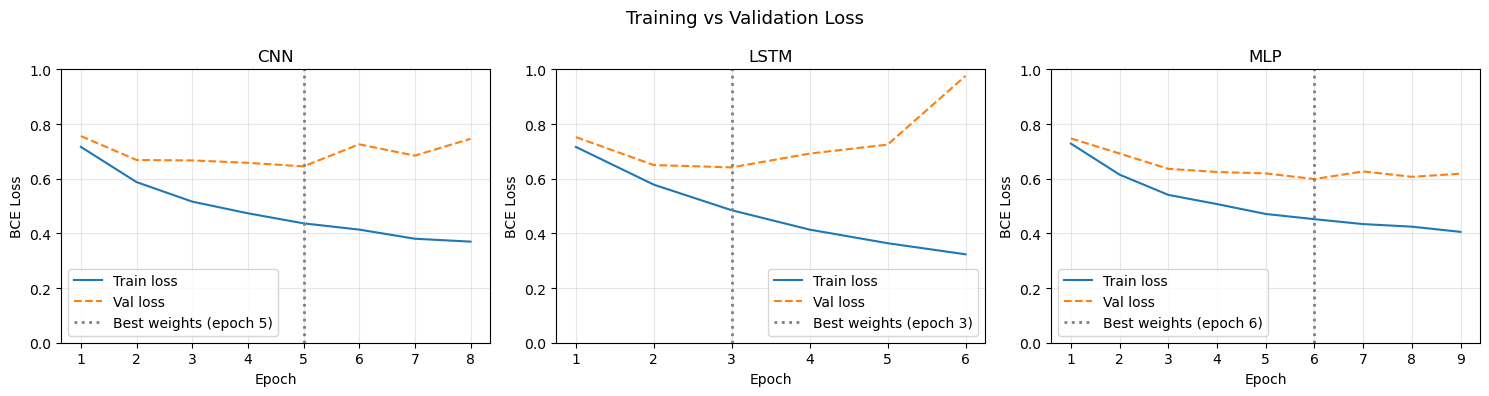

In [192]:
def plot_losses(train_losses, val_losses, model_name, ax):
    epochs = range(1, len(train_losses) + 1)
    best_epoch = val_losses.index(min(val_losses)) + 1

    ax.plot(epochs, train_losses, label="Train loss", linewidth=1.5)
    ax.plot(epochs, val_losses, label="Val loss", linewidth=1.5, linestyle="--")
    ax.axvline(x=best_epoch, color="grey", linewidth=2, linestyle=":", label=f"Best weights (epoch {best_epoch})")

    ax.set_title(model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_ylim(bottom=0, top=1)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_losses(cnn_train_losses, cnn_val_losses, "CNN",  axes[0])
plot_losses(lstm_train_losses, lstm_val_losses, "LSTM",  axes[1])
plot_losses(mlp_train_losses, mlp_val_losses, "MLP",  axes[2])
plt.suptitle("Training vs Validation Loss", fontsize=13)
plt.tight_layout()
plt.show()

histories = {
    "mlp_train": mlp_train_losses, "mlp_val": mlp_val_losses,
    "cnn_train": cnn_train_losses, "cnn_val": cnn_val_losses,
    "lstm_train": lstm_train_losses, "lstm_val": lstm_val_losses,
}

The figure shows that all three models learn useful patterns early, but begin to overfit after a few epochs. In each case, training loss steadily decreases, while validation loss improves at first and then levels off or rises. This widening gap suggests the models continue fitting the training data while losing generalization performance, making the dotted early-stopping checkpoints the best saved weights.

The CNN shows the most stable behavior, with validation loss improving until around epoch 5 and only increasing slightly afterward, suggesting solid generalization. The LSTM overfits the fastest, reaching its best validation loss by epoch 3 before worsening sharply, likely because its capacity is too high (it does have the most neurons by far) for the limited data. The MLP is the most balanced, with the flattest validation curve and the smallest train–validation gap, suggesting that a simpler architecture may be best suited for this task.

# Section the Seventh: Prediction Metrics

In [193]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare test data 
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)


def get_predictions(model, X):
    model.eval()
    
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).int()
    
    return preds.cpu().numpy()


def evaluate_model(model, X, y_true):
    preds = get_predictions(model, X)

    return {
        "Precision": precision_score(y_true, preds, average="macro"),
        "Recall": recall_score(y_true, preds, average="macro"),
        "F1": f1_score(y_true, preds, average="macro"),
        "Accuracy": accuracy_score(y_true, preds)
    }


# Run evaluation
mlp_results = evaluate_model(mlp_model, X_test_tensor, y_test)
cnn_results = evaluate_model(cnn_model, X_test_tensor, y_test)
lstm_results = evaluate_model(lstm_model, X_test_tensor, y_test)

import pandas as pd

mlp_table = pd.DataFrame([mlp_results], index=["MLP"])
cnn_table = pd.DataFrame([cnn_results], index=["CNN"])
lstm_table = pd.DataFrame([lstm_results], index=["LSTM"])

final_table = pd.concat([cnn_table, lstm_table, mlp_table])

print("Model Comparison Table (all thresholds set to 0.5):")
display(final_table)

In [194]:
import pandas as pd

mlp_table = pd.DataFrame([mlp_results], index=["MLP"])
cnn_table = pd.DataFrame([cnn_results], index=["CNN"])
lstm_table = pd.DataFrame([lstm_results], index=["LSTM"])

final_table = pd.concat([cnn_table, lstm_table, mlp_table])

print("Model Comparison Table (all thresholds set to 0.5):")
display(final_table)

Model Comparison Table (all thresholds set to 0.5):


,Precision,Recall,F1,Accuracy
CNN,0.708985,0.724945,0.704953,0.601786
LSTM,0.702952,0.743134,0.720505,0.598214
MLP,0.696590,0.730181,0.712109,0.603571


This comparison shows that the MLP and CNN perform very similarly overall, while the LSTM lags slightly behind. The small differences suggest that all three models are able to learn useful structure from the sentence embeddings, but the simpler architectures appear to use those pretrained features more efficiently. This aligns with the loss curves, where the MLP and CNN showed more stable validation behavior than the LSTM.

The MLP appears to be the strongest and most balanced model, likely achieving the best trade-off between learning capacity and generalization. The CNN is close behind, suggesting that local sequential patterns still add some value even when using rich embeddings as input. By contrast, the LSTM’s weaker performance is consistent with its earlier overfitting, indicating that the recurrent structure may be unnecessarily complex for this task.

Overall, the results suggest that simpler models are sufficient when working with strong 768-dimensional sentence embeddings, and that added sequential complexity does not necessarily improve performance.

### Per-Class Threshold Tuning

The default prediction threshold of 0.5 is arbitrary. Because the minority classes are rare, the model's probabilities for a genuine positive or negative sentence often land in the 0.3–0.45 range, so they get called negative. Lowering the threshold for those classes recovers recall at a precision cost, and the right trade-off is different for each label.

The code above sweeps thresholds from 0.3 to 0.7 on the validation set and picks the one maximising per-label binary F1. The test set is not touched during this search, thresholds are hyperparameters and using the test set to pick them would be another form of leakage. The resulting thresholds are reported alongside the F1 they achieve on the validation set; the tuned models are then re-evaluated on the holdout in the table below.


In [204]:
from sklearn.metrics import f1_score
import numpy as np
import torch

def tune_thresholds(model, X, y_true, label_names=["Positive", "Negative", "Neutral"]):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(model(X_tensor)).numpy()

    best_thresholds = {}
    thresholds = np.arange(0.3, 0.7, 0.05)

    for i, label in enumerate(label_names):
        y_true_i = y_true[:, i]
        baseline_f1 = f1_score(y_true_i, (probs[:, i] >= 0.5).astype(int), zero_division=0)
        best_t, best_f1 = 0.5, 0.0
        for t in thresholds:
            preds = (probs[:, i] >= t).astype(int)
            f1 = f1_score(y_true_i, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        best_thresholds[label] = {
            "F1 @ 0.5": round(baseline_f1, 3),
            "Best threshold": round(float(best_t), 2),
            "F1 @ best": round(best_f1, 3),
        }

    return best_thresholds


cnn_thresholds  = tune_thresholds(cnn_model,  X_val, y_val)
lstm_thresholds = tune_thresholds(lstm_model, X_val, y_val)
mlp_thresholds  = tune_thresholds(mlp_model,  X_val, y_val)

rows = []
for model_name, thresholds in [("CNN", cnn_thresholds), ("LSTM", lstm_thresholds), ("MLP", mlp_thresholds)]:
    for label, vals in thresholds.items():
        rows.append({"Model": model_name, "Label": label, **vals})

display(pd.DataFrame(rows).set_index(["Model", "Label"]))

F1 @ 0.5  Best threshold  F1 @ best
Model Label                                        
CNN   Positive     0.481            0.35      0.548
      Negative     0.713            0.55      0.720
      Neutral      0.799            0.30      0.820
LSTM  Positive     0.525            0.35      0.558
      Negative     0.689            0.50      0.689
      Neutral      0.807            0.35      0.827
MLP   Positive     0.538            0.30      0.587
      Negative     0.739            0.50      0.739
      Neutral      0.805            0.35      0.821

The table shows that threshold tuning consistently improves class-level F1 scores, with the largest gains appearing for the Positive class across all three architectures. At the default 0.5 threshold, Positive is clearly the most difficult label, with F1 scores ranging from 0.481 (CNN) to 0.538 (MLP), but lowering the threshold to 0.30–0.35 raises performance substantially, reaching 0.587 for the MLP, the best result overall for this class. By contrast, the Negative class is already relatively stable, with only minimal or no improvement after threshold adjustment, suggesting that 0.5 is already close to optimal. Neutral remains the strongest-performing class for every model, achieving the highest F1 scores overall and showing small but consistent gains when the threshold is reduced to 0.30–0.35, peaking at 0.827 for the LSTM. Across models, this suggests that threshold optimization is most valuable for improving weaker or less confidently predicted classes, while already separable classes benefit only marginally.

# Section the Eigth: Visualising the Performance

## Confusion Matrices

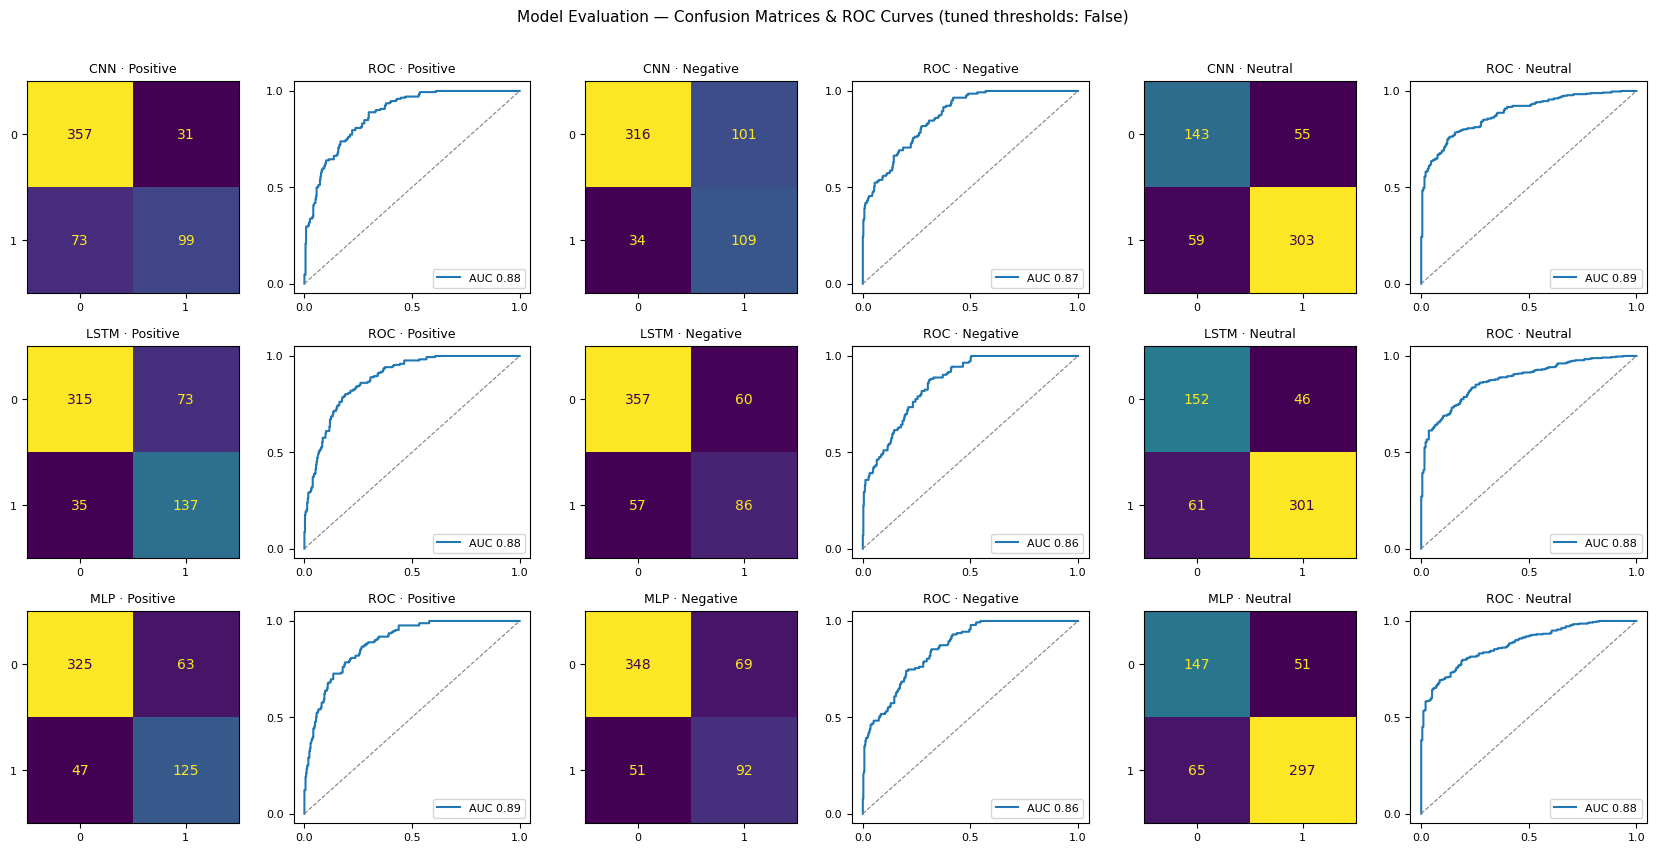

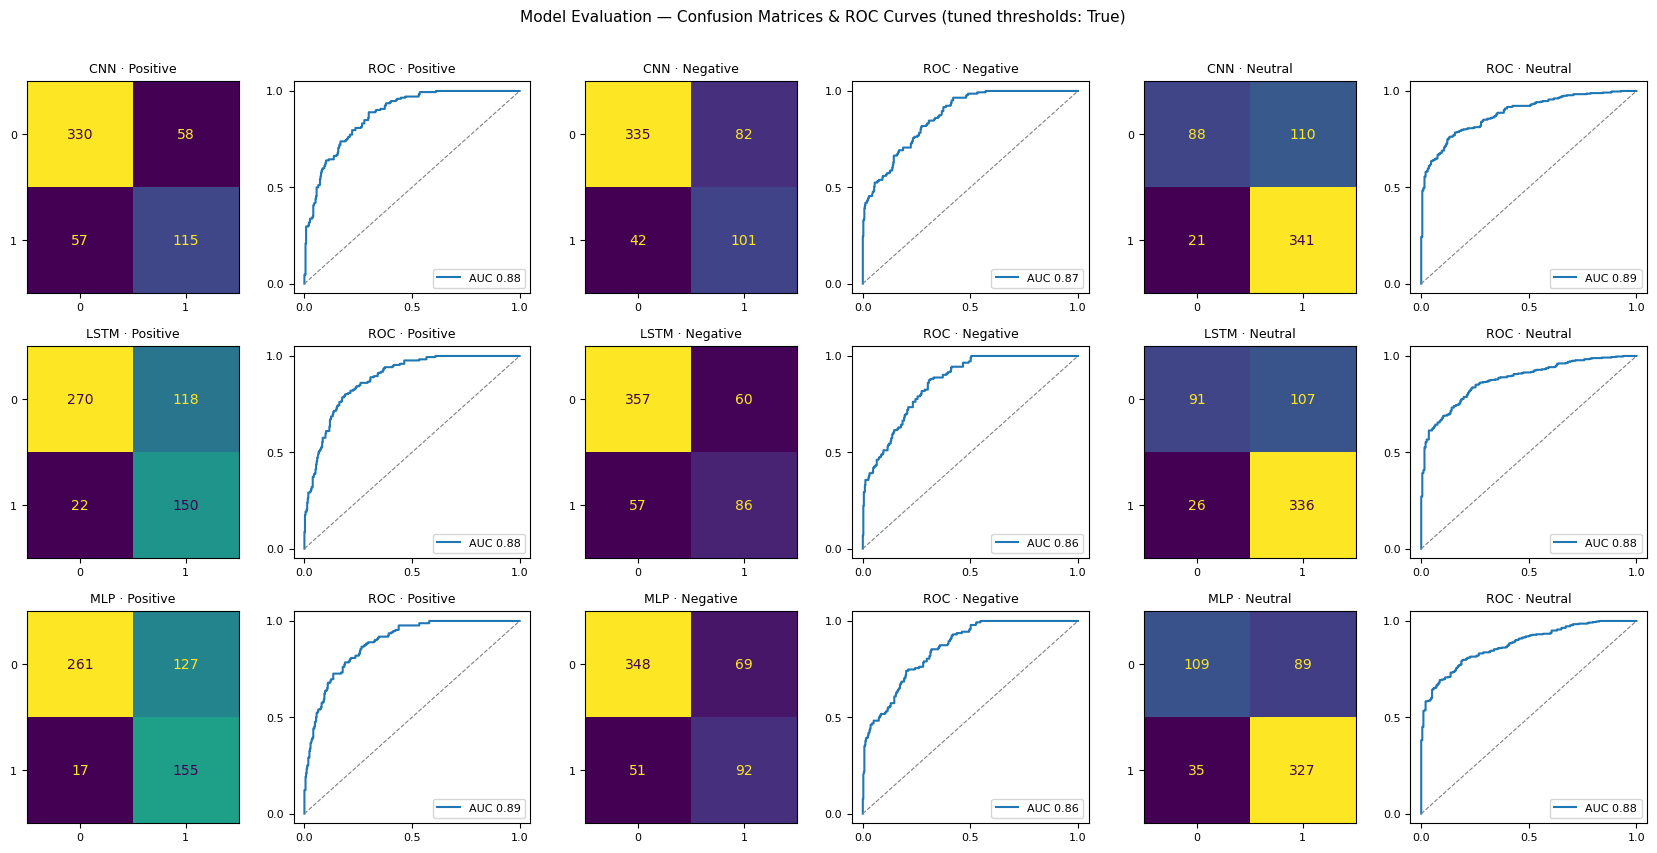

In [209]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import torch

def visualize_all_models(models_dict, thresholds_dict, X_test, y_test, label_names=["Positive", "Negative", "Neutral"], tuned_thresholds=True):
    """
    models_dict:     {"CNN": cnn_model, "LSTM": lstm_model, "MLP": mlp_model}
    thresholds_dict: {"CNN": cnn_thresholds, "LSTM": lstm_thresholds, "MLP": mlp_thresholds}
    tuned_thresholds: If True, use thresholds_dict for predictions; otherwise, use default threshold of 0.5.
    One row per model, columns: [CM pos, CM neg, CM neu, ROC pos, ROC neg, ROC neu]
    """
    n_models = len(models_dict)
    n_labels = len(label_names)
    n_cols   = n_labels * 2

    fig, axes = plt.subplots(
        n_models, n_cols,
        figsize=(n_cols * 2.8, n_models * 2.8)
    )

    X_tensor = torch.tensor(X_test, dtype=torch.float32)

    for row, (model_name, model) in enumerate(models_dict.items()):
        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(model(X_tensor)).numpy()

        if tuned_thresholds:
            # Build preds using the per-label best threshold for this model
            model_thresholds = thresholds_dict[model_name]
            preds = np.stack([
                (probs[:, i] >= model_thresholds[label]["Best threshold"]).astype(int)
                for i, label in enumerate(label_names)
            ], axis=1)
        else:
            preds = (probs >= 0.5).astype(int)

        for i, label in enumerate(label_names):
            y_true  = y_test[:, i]
            y_pred  = preds[:, i]
            y_score = probs[:, i]

            cm_ax  = axes[row, i * 2]
            roc_ax = axes[row, i * 2 + 1]

            # --- Confusion matrix ---
            cm = confusion_matrix(y_true, y_pred)
            ConfusionMatrixDisplay(cm).plot(ax=cm_ax, colorbar=False)
            cm_ax.set_title(f"{model_name} · {label}", fontsize=9)
            cm_ax.set_xlabel(""); cm_ax.set_ylabel("")
            cm_ax.tick_params(labelsize=8)

            # --- ROC ---
            if len(set(y_true)) > 1:
                fpr, tpr, _ = roc_curve(y_true, y_score)
                roc_auc = auc(fpr, tpr)
                roc_ax.plot(fpr, tpr, linewidth=1.5, label=f"AUC {roc_auc:.2f}")
                roc_ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="grey")
                roc_ax.legend(fontsize=8, loc="lower right")
            else:
                roc_ax.text(0.5, 0.5, "n/a", ha="center", va="center", fontsize=8)

            roc_ax.set_xticks([0, 0.5, 1]); roc_ax.set_yticks([0, 0.5, 1])
            roc_ax.tick_params(labelsize=8)
            roc_ax.set_title(f"ROC · {label}", fontsize=9)

    plt.suptitle(f"Model Evaluation — Confusion Matrices & ROC Curves (tuned thresholds: {tuned_thresholds})", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

# Call the function for both scenarios
visualize_all_models(
    {"CNN": cnn_model, "LSTM": lstm_model, "MLP": mlp_model},
    {"CNN": cnn_thresholds, "LSTM": lstm_thresholds, "MLP": mlp_thresholds},
    X_test, y_test,
    tuned_thresholds=False
)

visualize_all_models(
    {"CNN": cnn_model, "LSTM": lstm_model, "MLP": mlp_model},
    {"CNN": cnn_thresholds, "LSTM": lstm_thresholds, "MLP": mlp_thresholds},
    X_test, y_test,
    tuned_thresholds=True
)


Comparing the untuned (0.5) and tuned per-class thresholds figures, the clearest conclusion is that threshold tuning mainly shifts the precision–recall balance rather than changing the models’ underlying ranking ability. This is expected because the ROC curves and AUC values remain essentially identical between the two figures (roughly 0.86–0.89 across all classes and models), showing that the models’ separability has not changed—only the decision boundary used to convert probabilities into labels.

The biggest gains occur for the Positive and Neutral classes, where lowering the thresholds substantially reduces false negatives and improves recall. For example, the MLP Positive matrix improves from 125 true positives / 47 false negatives to 155 true positives / 17 false negatives, a major recall boost that aligns with the earlier F1 gains. Similar improvements are visible for Neutral across all models, where the tuned thresholds produce many more true positives at the cost of additional false positives. This suggests these classes were previously being predicted too conservatively at 0.5.

By contrast, the Negative class changes very little, especially for the LSTM and MLP where the optimal threshold remains 0.50, confirming that the default threshold was already close to ideal. Overall, the tuned version is clearly preferable because it improves weaker classes without affecting class separability, making the predictions more balanced across labels and better aligned with class-specific objectives.

## Two Paragraph Applications

We have many metrics and evaluations at this point, but let's return to an application. How would this work with a coherant set of text?

Here we apply the new models to plain paragraphs (the same as were used in assignment one), sentences by sentences, for a more human level evaluation. 

In [210]:
def encode_sentences(sentences, max_length=128):
    """
    Convert raw sentences into frozen DistilBERT token embeddings.
    
    Returns:
        numpy array of shape (n_sentences, seq_len, 768)
    """
    inputs = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    with torch.no_grad():
        token_embeddings = distilbert(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        ).last_hidden_state

    return token_embeddings.numpy()

def predict_manual_segment(sentences, manual_labels, model, thresholds):

    labels = ["Positive", "Negative", "Neutral"]

    manual_df = pd.DataFrame(
        manual_labels,
        columns=[f"{label}_manual" for label in labels]
    )
    manual_df["sentence"] = sentences

    embeddings = torch.tensor(
        encode_sentences(sentences),
        dtype=torch.float32
    )

    model.eval()
    with torch.no_grad():
        logits = model(embeddings)
        probs = torch.sigmoid(logits).cpu().numpy()

    for i, label in enumerate(labels):
        t = thresholds[label]["Best threshold"]
        manual_df[f"{label}_score"] = probs[:, i]
        manual_df[f"{label}_pred"] = (probs[:, i] >= t).astype(int)

    return manual_df

In [97]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt


def plot_segment_heatmaps(manual_df, model_name = ""):
    """
    Visualize predicted probabilities, manual labels,
    and TP/TN/FP/FN outcomes for manually labeled segments.
    """

    labels = ["Positive", "Negative", "Neutral"]

    score_matrix = manual_df[
        [f"{label}_score" for label in labels]
    ].values

    manual_matrix = manual_df[
        [f"{label}_manual" for label in labels]
    ].values

    pred_matrix = manual_df[
        [f"{label}_pred" for label in labels]
    ].values

    # -----------------------------------------
    # Build outcome matrix
    # -----------------------------------------
    outcome_matrix = np.zeros_like(pred_matrix)

    for i in range(pred_matrix.shape[0]):
        for j in range(pred_matrix.shape[1]):

            m = manual_matrix[i, j]
            p = pred_matrix[i, j]

            if m == 1 and p == 1:
                outcome_matrix[i, j] = 1  # TP
            elif m == 0 and p == 0:
                outcome_matrix[i, j] = 0  # TN
            elif m == 0 and p == 1:
                outcome_matrix[i, j] = 2  # FP
            elif m == 1 and p == 0:
                outcome_matrix[i, j] = 3  # FN

    n_sentences = len(manual_df)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"{model_name} Segment Prediction Heatmaps", fontsize=16)

    # =========================================================
    # 1️⃣ Prediction Probability Panel
    # =========================================================
    im1 = axes[0].imshow(score_matrix, aspect="auto", vmin=0, vmax=1)
    axes[0].set_title("Predicted Probabilities")

    axes[0].set_xticks(np.arange(len(labels)))
    axes[0].set_xticklabels(labels)
    axes[0].set_yticks(np.arange(n_sentences))
    axes[0].set_yticklabels(range(1, n_sentences + 1))

    for i in range(n_sentences):
        for j in range(len(labels)):
            axes[0].text(j, i, f"{score_matrix[i, j]:.2f}",
                         ha="center", va="center")

    plt.colorbar(im1, ax=axes[0]).set_label("Probability")

    # =========================================================
    # 2️⃣ Manual Labels Panel
    # =========================================================
    manual_cmap = ListedColormap(["#F0F0F0", "#029386"])
    im2 = axes[1].imshow(
        manual_matrix,
        aspect="auto",
        cmap=manual_cmap,
        vmin=0,
        vmax=1
    )

    axes[1].set_title("Manual Labels")
    axes[1].set_xticks(np.arange(len(labels)))
    axes[1].set_xticklabels(labels)
    axes[1].set_yticks(np.arange(n_sentences))
    axes[1].set_yticklabels(range(1, n_sentences + 1))

    for i in range(n_sentences):
        for j in range(len(labels)):
            axes[1].text(j, i, str(int(manual_matrix[i, j])),
                         ha="center", va="center")

    plt.colorbar(im2, ax=axes[1]).set_label("1 = Assigned")

    # =========================================================
    # 3️⃣ Outcome Panel
    # =========================================================
    outcome_cmap = ListedColormap([
        "#4C72B0",  # TN
        "#55A868",  # TP
        "#FFB000",  # FP
        "#C44E52"   # FN
    ])

    im3 = axes[2].imshow(
        outcome_matrix,
        aspect="auto",
        cmap=outcome_cmap,
        vmin=0,
        vmax=3
    )

    axes[2].set_title("Prediction Outcome")
    axes[2].set_xticks(np.arange(len(labels)))
    axes[2].set_xticklabels(labels)
    axes[2].set_yticks(np.arange(n_sentences))
    axes[2].set_yticklabels(range(1, n_sentences + 1))

    outcome_labels = {0: "TN", 1: "TP", 2: "FP", 3: "FN"}

    for i in range(n_sentences):
        for j in range(len(labels)):
            axes[2].text(
                j, i,
                outcome_labels[outcome_matrix[i, j]],
                ha="center",
                va="center",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

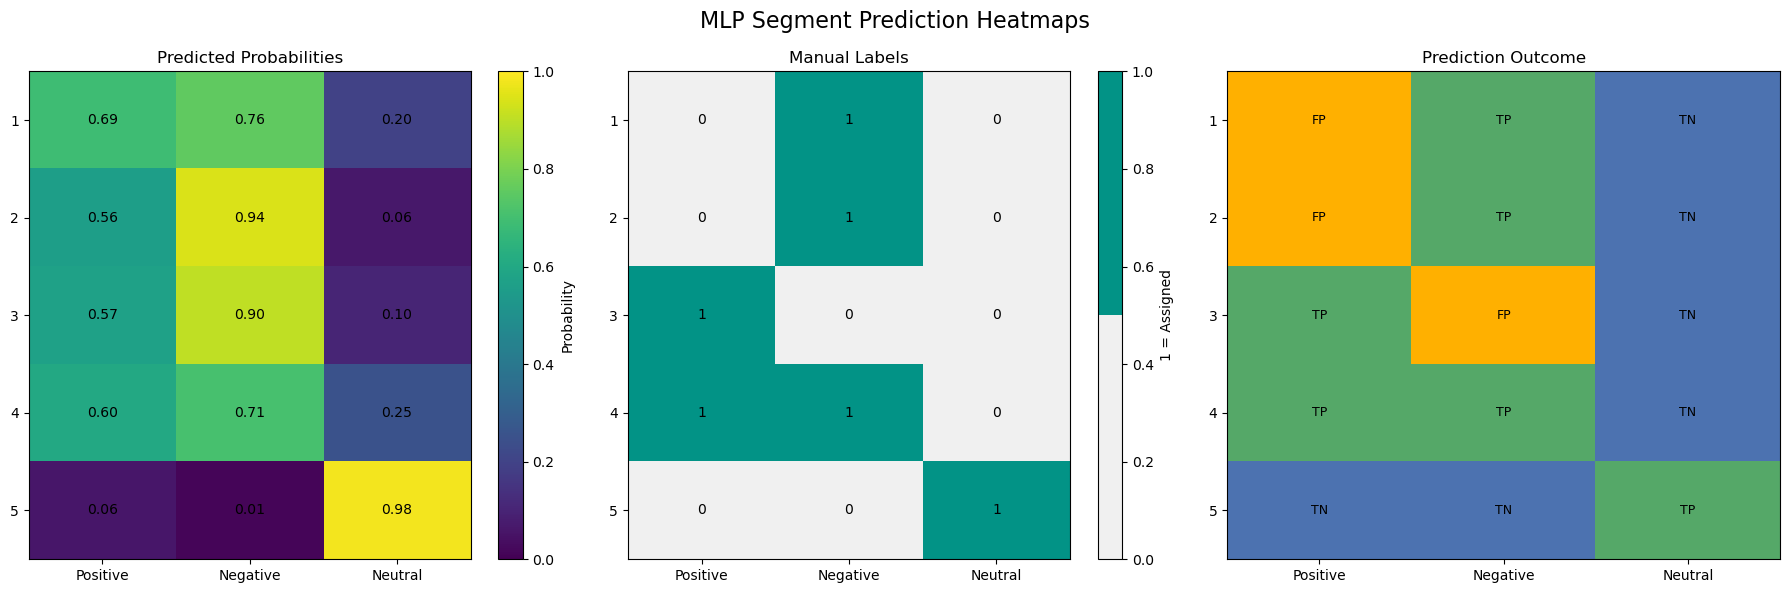

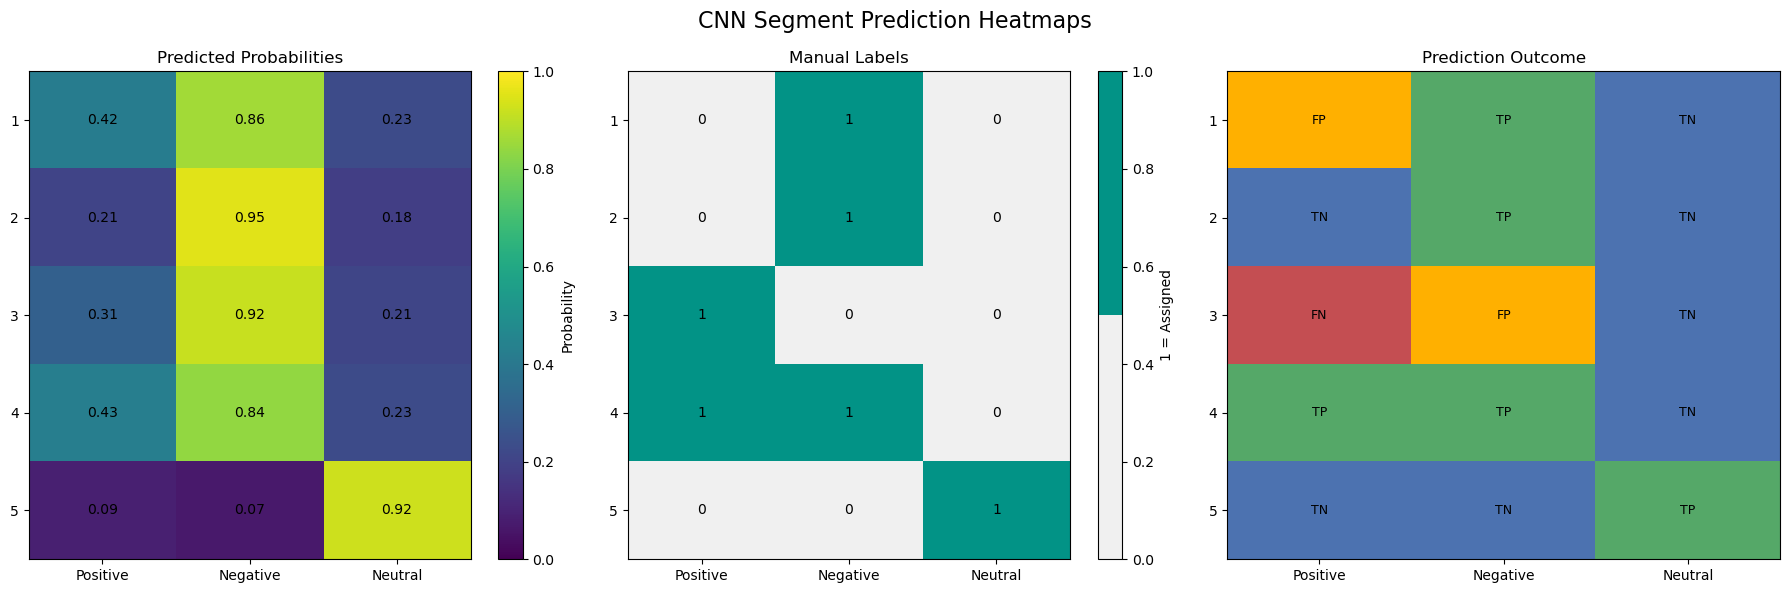

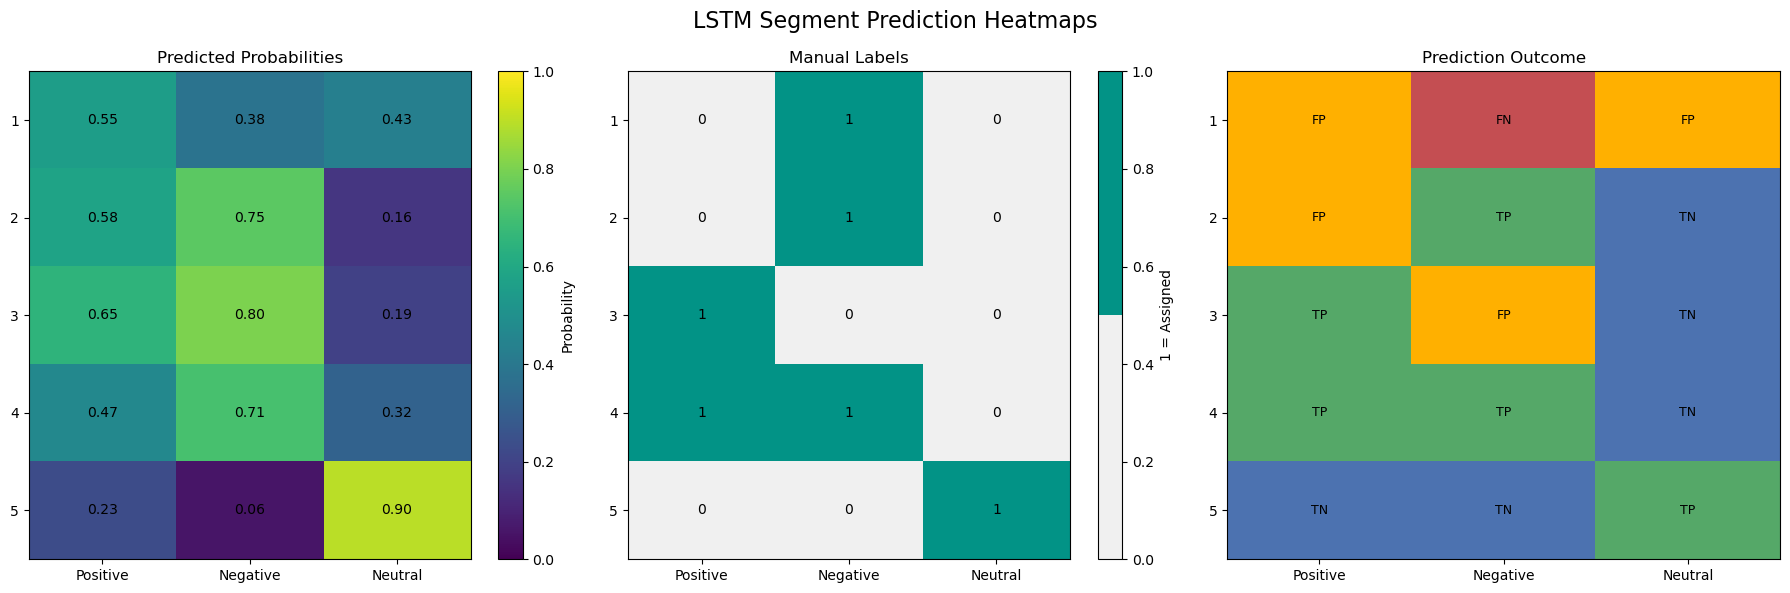

In [212]:
manual_sentences = [
    "Later, Connor told me that he heard Mr. Kelleher say that he was sorry he ever left Ireland.",
    "He said it would have been better if Thomas had died at home where he could be buried in the ground with a priest to say words over him, instead of being tossed into the ocean like so much refuse",
    "Michael argued that if the Kellehers had stayed home, they would likely be dead from starvation by now.",
    "“At least we have food on the ship, however poor it is,” he said.”",
    "Connor agreed."
]


# Multi-label manual assignment (Positive, Negative, Neutral)
manual_labels = [
    [0, 1, 0],  # Negative
    [0, 1, 0],  # Negative
    [1, 0, 0],  # Positive 
    [1, 1, 0],  # Negative + Positive
    [0, 0, 1]   # Neutral
]


manual_results_cnn  = predict_manual_segment(manual_sentences, manual_labels, cnn_model,  cnn_thresholds)
manual_results_lstm = predict_manual_segment(manual_sentences, manual_labels, lstm_model, lstm_thresholds)
manual_results_mlp  = predict_manual_segment(manual_sentences, manual_labels, mlp_model,  mlp_thresholds)

plot_segment_heatmaps(manual_results_mlp, "MLP")
plot_segment_heatmaps(manual_results_cnn, "CNN")
plot_segment_heatmaps(manual_results_lstm, "LSTM")

The neural models perform with mixed but interpretable results on this passage. The MLP does best at 9/15, and its errors are telling, sentences 1 and 2 both get flagged as Positive when they are clearly not. Sentence 1 is Connor relaying overheard regret ("sorry he ever left Ireland"), and sentence 2 is the grim ocean burial remark. Both carry a kind of narrative distance that likely confuses the MLP: they are reported speech, not direct emotional expression, and the model seems to latch onto surface-level named entities and storytelling cadence rather than the underlying grief. Sentence 3's Negative being a FP is the same problem seen across all three models. Michael's argument is phrased as a negative conditional but carries a pro-emigration stance, and none of the neural models handle that inversion well.

The CNN introduces a more serious error: a FN on sentence 3's Positive label, meaning it not only misreads the sentiment but completely misses the one class that matters most for that sentence. The LSTM's worst moment is sentence 1, where it produces FP, FN, FP across all three classes simultaneously — a total misread of what is essentially a quiet, sorrowful piece of reported dialogue. The LSTM's sequential architecture should theoretically help with narrative flow, but here it seems to overfit to earlier context and loses the plot by sentence 1's end.

Overall, the passage rewards models that can handle reported speech and conditional framing, which none of the three do confidently. The SVM, for reference, handled this passage considerably better.

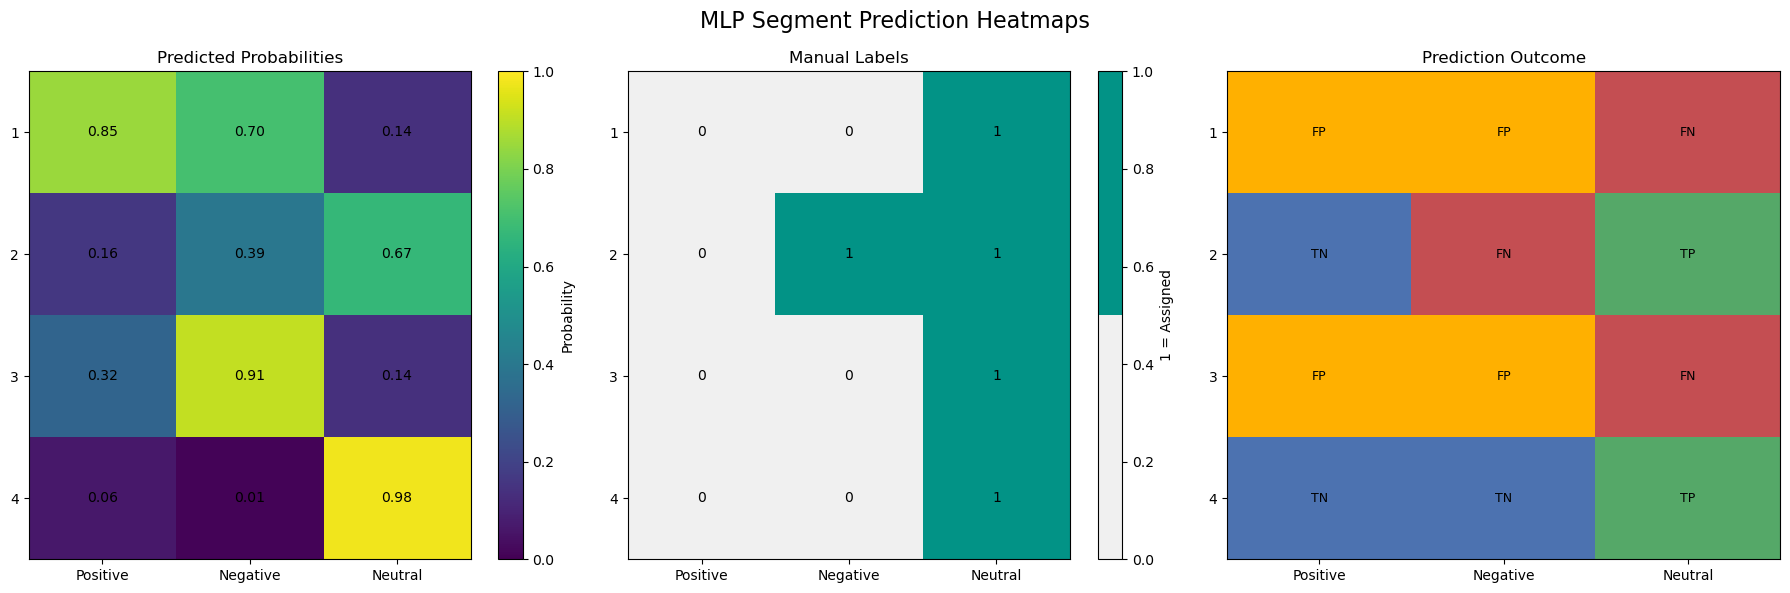

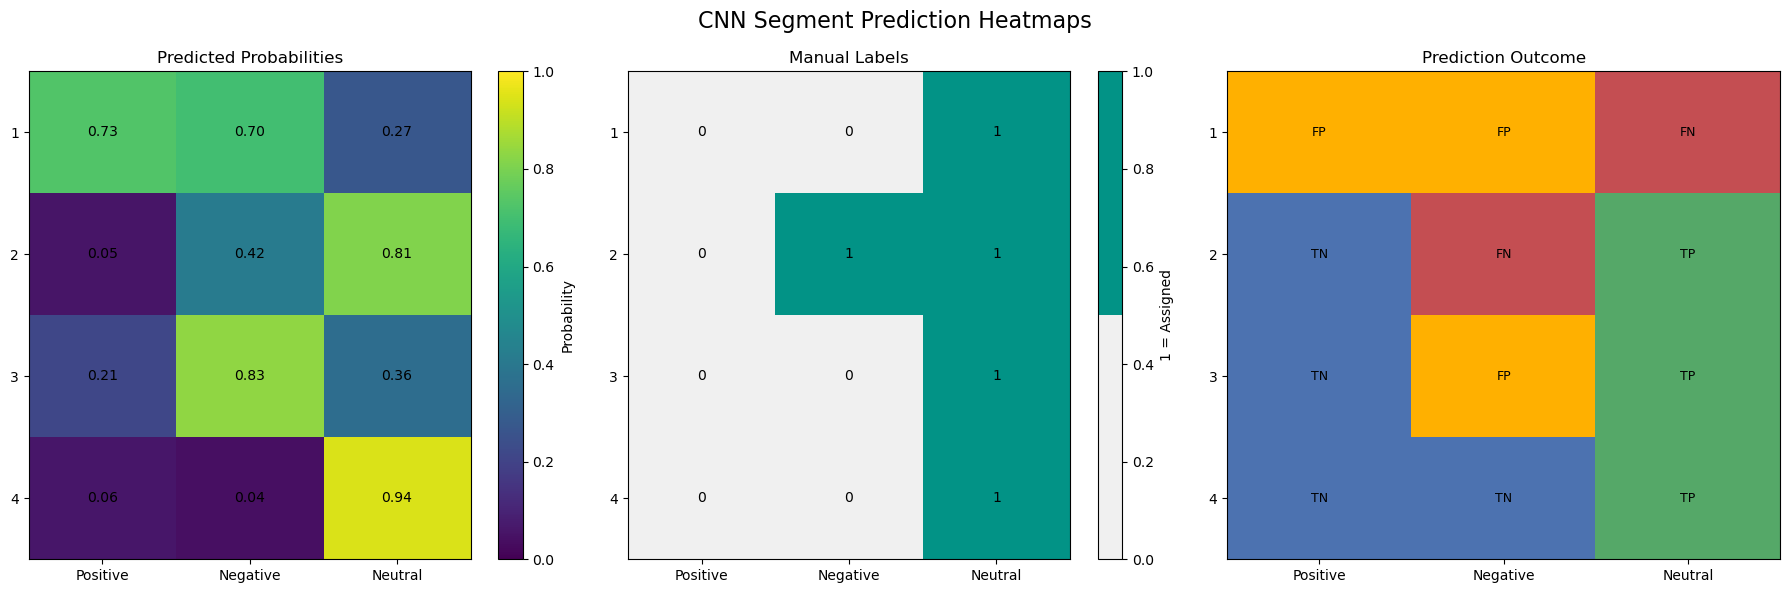

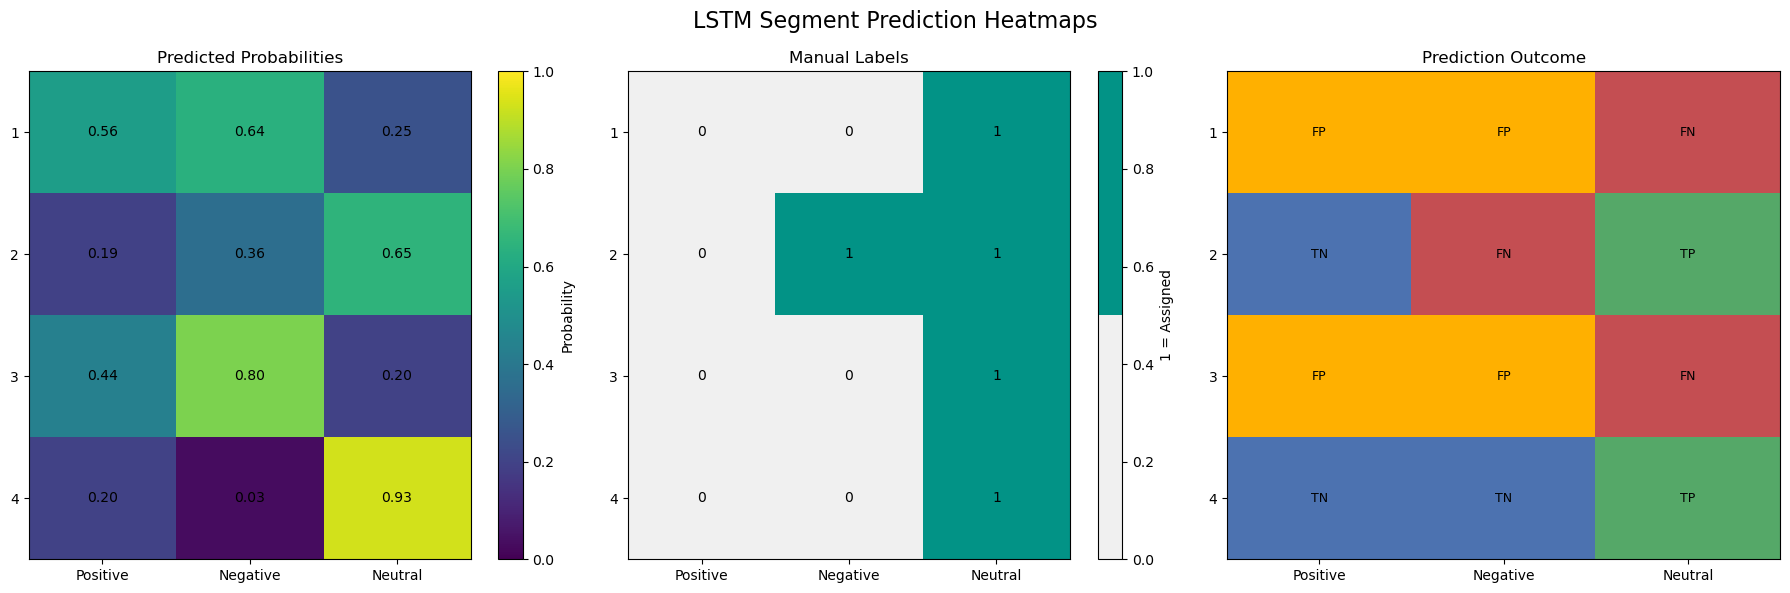

In [216]:
manual_sentences = [
    "The wind is howling outside, but all is safe and peaceful in this little house.",
    "We still do not have much.",
    "We will have to husband our supplies very carefully to get through this winter, but I am certain we will make it.",
    "And tomorrow I will start on a quilt."
    ]



# Multi-label manual assignment (Positive, Negative, Neutral)
manual_labels = [
    [0, 0, 1],  # Neutral
    [0, 1, 1],  # Neutral, negative
    [0, 0, 1],  # Neutral 
    [0, 0, 1]  # Neutral
]


manual_results_cnn  = predict_manual_segment(manual_sentences, manual_labels, cnn_model,  cnn_thresholds)
manual_results_lstm = predict_manual_segment(manual_sentences, manual_labels, lstm_model, lstm_thresholds)
manual_results_mlp  = predict_manual_segment(manual_sentences, manual_labels, mlp_model,  mlp_thresholds)


plot_segment_heatmaps(manual_results_mlp, "MLP")
plot_segment_heatmaps(manual_results_cnn, "CNN")
plot_segment_heatmaps(manual_results_lstm, "LSTM")


This passage is where all three neural models struggle most, and the reason is clear from the text itself: every sentence is calm, declarative, and understated. "The wind is howling outside, but all is safe and peaceful in this little house" contains a dramatic word ("howling") immediately neutralized by "safe and peaceful", a contrast that requires genuine contextual reading to resolve as Neutral. The MLP and LSTM both fire FP on Positive for this sentence, suggesting they are anchoring on the domestic warmth of "safe and peaceful" without registering the whole.

Sentence 2 ("We still do not have much") and sentence 3 ("husband our supplies very carefully") are where the Negative label appears, and all three models have difficulty with it. The language is quiet and restrained, there is no exclamation, no strong negative vocabulary, just the steady acknowledgment of scarcity. The LSTM is worst here, producing the most FPs on Positive across the paragraph and essentially reading this survival-mode winter journal entry as optimistic throughout. The CNN does best on this paragraph, correctly suppressing Positive predictions on sentences 2 and 4 and getting Neutral TPs on the back half, it seems slightly better calibrated for understated text.

The core challenge this paragraph exposes is that all three models appear biased toward emotional intensity as a signal (which is actually intentional, in that we have decided to value recall over precision). When the writing is deliberately quiet, they misattribute the absence of negative language as positivity. The SVM and logistic regression, for reference, also struggled here (thought actually performed better) but for different structural reasons.


# Section the Nineth: Exectutive Summary

This project applies multi-label sentiment classification to the *Dear Canada* anthology, a series of Canadian children's historical fiction books written from the perspective of young immigrant girls. The goal is to detect how immigration is represented sentimentally across the text, where each sentence may be simultaneously positive, negative, and/or neutral about the immigrant experience.

**Data.** Sentences were manually extracted and labeled across six books spanning 1666 to 1926. Positive and negative immigration sentiment are rare, accounting for roughly 7.5% of the corpus each. To address this severe imbalance, Claude LLM was used to generate two surface-level paraphrases per minority-class sentence (synonym substitution, reordering, minor additions). In addition, the most negative and most positive sentences, according to the previous assignments logistic model, were selectively labeled to add to the data pool. That accounts for a doublings of each minority share. The final training+validation corpus contains 3,018 sentences: ~21% positive, ~22% negative, ~58% neutral. Data splits were constructed using GroupShuffleSplit to ensure augmented clones never appear on opposite sides of a train/test boundary.

**Pipeline.** All sentences were embedded using frozen DistilBERT, producing a 128×768 token-level representation per sentence. Three neural classifiers were trained on these embeddings: an MLP (mean-pooling before classification), a CNN (two convolutional layers with global max-pooling), and a bidirectional LSTM (reading full sequences in both directions). All three use Binary Cross-Entropy loss with per-class weighting and Adam optimization. Early stopping with weight restoration was applied against validation loss.

**Results.** All three models achieve macro-averaged F1 scores in the 0.70–0.72 range, with accuracy near 60%. The MLP and CNN perform comparably and most stably; the LSTM overfits the fastest, likely because its parameter count is large relative to the ~2,500 unique training sentences. Threshold tuning (sweeping 0.30–0.70 on validation) improves minority-class F1 meaningfully, particularly for the Positive class, where the best threshold drops to 0.30–0.35 across all models. Neutral classification is substantially stronger than minority-class classification, consistent with its training volume advantage.

**Key finding.** The core challenge is conceptual, not just statistical: immigration sentiment is often indirect. A sentence like *"we would have starved at home"* is positive about immigration but reads as negative in isolation. The models detect these cases better than the first assignment's logistic and SVM baselines, and their probability outputs usefully reflect annotator uncertainty. Nevertheless, the primary bottleneck is labeled data volume. 

# Section the Tenth: Acknowelgements

## AI Statement
As stated before, I used Claude to create augmentation sentences. Elsewhere, I used both Claude and ChatGPT to help ideate, research, and write or revise sections. 
This is the augmentation link: https://claude.ai/share/3879ac3d-234d-421e-ba1b-912de68dc7ad 
This is my other primary Claude chat: https://claude.ai/share/a77409ff-2ba3-4328-92b3-eae217e16ab1
This is my primary ChatGPT chat: https://chatgpt.com/share/69ce9b7d-2e40-83e9-8664-6af5779d9bdc

## References
ReferencesCodeEmporium. (2024, March 18). How much training data does a neural network need? YouTube. https://www.youtube.com/watch?
v=XVXczyheik0

GeeksforGeeks. (2023, April 17). Text augmentation techniques in NLP. GeeksforGeeks. https://www.geeksforgeeks.org/nlp/text-augmentation-techniques-in-nlp/

Skillcate AI. (2022, July 27). Sentiment Analysis with LSTM | Deep Learning with Keras | Neural Networks | Project#8. YouTube. https://www.youtube.com/watch?v=oWo9SNcyxlI

# Appendix


### Ingesting the books

I read the htm(l) files from the EPUB and assembled them into a txt file. There is some variance in the formatting and file types in the EPUBS, which I mostly adjusted manually, because I only had to do it once, it wasn't very hard, and making the input system infinitely robust just wasn't worth the time. 


Separate to this pipeline, I have the following file:

file: extract_text.py


    import os
    from bs4 import BeautifulSoup

    input_folder = "htm_chapters"
    output_file = "dear_canada_clean.txt"

    all_text = []

    for filename in sorted(os.listdir(input_folder)):
        if filename.endswith(".htm"):			# can be htm or html, just change this line
            path = os.path.join(input_folder, filename)

            with open(path, "r", encoding="utf-8") as f:
                soup = BeautifulSoup(f, "lxml")

                # remove junk
                for tag in soup(["script", "style"]):
                    tag.decompose()

                text = soup.get_text(separator="\n")
                all_text.append(f"\n\n===== {filename} =====\n\n")
                all_text.append(text)

    with open(output_file, "w", encoding="utf-8") as out:
        out.write("\n".join(all_text))

    print("Done! Check dear_canada_clean.txt")

<br>

Which is used in the terminal to read the EPUB,

% pip install beautifulsoup4 lxml

% unzip book.epub -d book_contents

% mkdir htm_chapters

% cp book_contents/OEBPS/*.htm htm_chapters/

% python extract_text.py 



In [ ]:
import re
import pandas as pd
from nltk.tokenize import sent_tokenize
import nltk
import os

books = {

    "SofS": {
        "file": "text_files/SofS.txt",
        "start_marker": "===== c01.htm =====",
        "end_marker": "===== cop.htm =====",
        "chapter_pattern": r"===== (c\d+)\.htm =====",
        "date_pattern": r"""
            \b
            (January|February|March|April|May|June|July|August|September|
             October|November|December)
            \s+\d{1,2},\s*\d{4}
            \b
        """
    },

    "FitS": {
        "file": "text_files/FitS.txt",
        "start_marker": "===== c01.htm =====",
        "end_marker": "===== cop.htm =====",
        "chapter_pattern": r"===== (c\d+)\.htm =====",
        "date_pattern": r"""
            \b
            (January|February|March|April|May|June|July|August|September|
             October|November|December)
            \s+\d{1,2}
            \b
        """
    },

    "DRtoF": {
        "file": "text_files/drtof.txt",
        "start_marker": "===== c01.htm =====",
        "end_marker": "===== cop.htm =====",
        "chapter_pattern": r"===== (c\d+)\.htm =====",
        "date_pattern": r"""
            \b(
                # Full date with weekday (handles broken lines)
                (?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday),?\s*
                (January|February|March|April|May|June|July|August|September|
                October|November|December)
                \s+\d{1,2}
                (?:\s*\n?\s*(?:st|nd|rd|th))?
                [\s,\n]*\d{4}

                |

                # Month + Year (January 1864)
                (January|February|March|April|May|June|July|August|September|
                October|November|December)
                \s+\d{4}

                |

                # Year only
                \b\d{4}\b
            )
        """
    },

    "PasWide": {
        "file": "text_files/PasWide.txt",
        "start_marker": "===== 9781443113342_epub_c01.htm =====",
        "end_marker": "===== 9781443113342_epub_cop_r1.htm =====",
        "chapter_pattern": r"===== 9781443113342_epub_c(\d+)\.htm =====",
        "date_pattern": r"""
            \b
            (January|February|March|April|May|June|July|August|September|
             October|November|December)
            \s+\d{1,2}
            \b
        """
    },

    "NbutC": {
        "file": "text_files/nbutc.txt",
        "start_marker": "===== ch1.html =====",
        "end_marker": "===== cop.html =====",
        "chapter_pattern": r"===== ch(\d+)\.html =====",
        "date_pattern": r"""
            \b
            (January|February|March|April|May|June|July|August|September|
             October|November|December)
            \s+\d{1,2}(?:st|nd|rd|th),\s*\d{4}
            \b
        """
    },

    "AinUTL": {
        "file": "text_files/AinUTL.txt",
        "start_marker": "===== ch1.html =====",
        "end_marker": "===== cop.html =====",
        "chapter_pattern": r"===== ch(\d+)\.html =====",
        "date_pattern": r"""
            \b
            le\s+\d{1,2}\s+
            (janvier|février|fevrier|mars|avril|mai|juin|juillet|août|aout|
             septembre|octobre|novembre|décembre|decembre)
            \s+\d{4}
            \b
        """
    }
}
# Process each book in the dictionary
book_dfs = {}

for book_name, book_info in books.items():
    with open(book_info["file"], "r", encoding="utf-8") as f:
        raw_text = f.read()

    start = raw_text.find(book_info["start_marker"])
    end = raw_text.find(book_info["end_marker"])
    diary_text = raw_text[start:end]

    sections = re.split(book_info["chapter_pattern"], diary_text)

    chapters = []
    for i in range(1, len(sections), 2):
        chapter_id = sections[i]
        text = sections[i+1]

        chapters.append({
            "book": book_name,
            "chapter_id": chapter_id,
            "text": text.strip()
        })

    chapters_df = pd.DataFrame(chapters)
    book_dfs[book_name] = chapters_df
    print(f"Chapters for {book_name}:")
    print(chapters_df.head())



This data is pretty clean, because it comes from a a quality digital first source. Front and back matter were already removed in the previous section, but there are many many dates (at the start of each diary entry) and chapter formatting which need to be removed. 

In [ ]:
def is_valid_sentence(s):
    if len(s) < 7:
        return False

    bad_endings = ("Mrs.", "Mr.", "Miss.", "Dr.", "“", '"')
    if s.endswith(bad_endings):
        return False

    return True


# Creating entry and sentence DataFrames

base_output_folder = "dataframes"
os.makedirs(base_output_folder, exist_ok=True)

entry_output_folder = os.path.join(base_output_folder, "entry_dfs")
sentence_output_folder = os.path.join(base_output_folder, "sentence_dfs")

os.makedirs(entry_output_folder, exist_ok=True)
os.makedirs(sentence_output_folder, exist_ok=True)



#for book_name, book_info in books.items():
    with open(book_info["file"], "r", encoding="utf-8") as f:
        raw_text = f.read()

    start = raw_text.find(book_info["start_marker"])
    end = raw_text.find(book_info["end_marker"])
    diary_text = raw_text[start:end]

    sections = re.split(book_info["chapter_pattern"], diary_text)

    all_entries = []
    all_sentences = []

    for i in range(1, len(sections), 2):
        chapter_id = sections[i]
        text = sections[i+1]

        # ---------------------------------------------------------
        # 1. Remove chapter header
        # ---------------------------------------------------------
        text = re.sub(
            r"^Dear Canada:.*?\n+",
            "",
            text,
            flags=re.DOTALL
        ).strip()

        # ---------------------------------------------------------
        # 2. Extract dated entries
        # ---------------------------------------------------------
        matches = list(re.finditer(book_info["date_pattern"], text, re.VERBOSE | re.IGNORECASE))

        for j, match in enumerate(matches):

            date = match.group()
            start = match.end()
            end = matches[j + 1].start() if j + 1 < len(matches) else len(text)

            entry_text = text[start:end]

            # -----------------------------------------------------
            # 3. Clean entry text
            # -----------------------------------------------------
            entry_text = re.sub(r"\n\s*\n", " ", entry_text)
            entry_text = re.sub(r"\s+", " ", entry_text).strip()

            entry_id = f"ch{chapter_id}_e{j+1}"

            all_entries.append({
                "book": book_name,
                "chapter_id": chapter_id,
                "entry_id": entry_id,
                "date": date,
                "entry_text": entry_text
            })

            # -----------------------------------------------------
            # 4. Sentence tokenize
            # -----------------------------------------------------
            sentences = sent_tokenize(entry_text)

            for sentence in sentences:

                sentence = sentence.strip()

                if is_valid_sentence(sentence):
                    all_sentences.append({
                        "book_name": book_name,
                        "chapter_id": chapter_id,
                        "entry_id": entry_id,
                        "date": date,
                        "sentence": sentence
                    })

    entries_df = pd.DataFrame(all_entries)
    sentences_df = pd.DataFrame(all_sentences)

    entries_df.to_csv(os.path.join(entry_output_folder, f"{book_name}_entries.csv"), index=False)
    sentences_df.to_csv(os.path.join(sentence_output_folder, f"{book_name}_sentences.csv"), index=False)

print(f"Diary entry and sentence DataFrames saved to folder: {entry_output_folder} and {sentence_output_folder}")